# Data Analysis & Visualization (Local Version)

## Setup
This notebook has been adapted for local execution.
It loads data from `../data/raw/insurance_claims.csv`.


In [ ]:
# Setup / Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go



In [ ]:
# Data Load

claimdf = pd.read_csv('../data/raw/insurance_claims.csv')

In [ ]:
#Verify data integrity

print(f"Dataset shape: {claimdf.shape}")
print(f"Memory usage: {claimdf.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

#The dataset size is manageable for local analysis without distributed computing needs.
# Dataset contains 1000 rows × 40 columns.
#Each row likely represents an individual insurance claim record.

Dataset shape: (1000, 40)
Memory usage: 1.28 MB


In [ ]:
#Get structure + metadata

claimdf.info()
claimdf.describe(include='all').T.head(15)
claimdf.isna().sum().sort_values(ascending=False).head(10)

print(claimdf.head(3))


# Initial scan confirms presence of both numerical and categorical variables with mixed data types.
# Some columns (e.g. _c39) appear empty or structural artifacts from CSV export.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [ ]:
# Removing _c39, since it is a fully blank row

claimdf = claimdf.drop(columns=['_c39'])

# Sanity Check
'_c39' in claimdf.columns  # should return False


#During the initial data inspection (claimdf.info()), one column (_c39) was found to contain 100% missing values and no observable business meaning.
#It was therefore removed from the dataset to simplify subsequent analysis and modeling.
#This variable likely originated as an artifact of CSV export (an empty trailing column).

False

In [ ]:
# List all unique values for all categorical columns

for col in claimdf.select_dtypes(include='object').columns:
    uniques = claimdf[col].dropna().unique()
    print(f"\n--- {col} ---")
    print(uniques)
    print(f"Unique count: {len(uniques)}")




--- policy_bind_date ---
['2014-10-17' '2006-06-27' '2000-09-06' '1990-05-25' '2014-06-06'
 '2006-10-12' '2000-06-04' '1990-02-03' '1997-02-05' '2011-07-25'
 '2002-05-26' '1999-05-29' '1997-11-20' '2012-10-26' '1998-12-28'
 '1992-10-19' '2005-06-08' '2004-11-15' '2014-12-28' '1992-08-02'
 '2002-06-25' '2005-11-27' '1994-05-27' '1991-02-08' '1996-02-02'
 '2013-12-05' '1990-09-20' '2002-07-18' '1990-02-08' '2014-03-04'
 '2000-02-18' '2008-06-19' '2003-08-01' '1992-04-04' '1991-01-13'
 '2010-08-08' '2003-03-09' '1993-02-03' '2002-11-25' '1997-07-27'
 '1995-05-08' '2012-08-30' '2006-04-30' '2003-04-13' '2007-12-05'
 '2006-08-21' '1990-01-08' '1990-03-18' '2008-01-07' '1997-03-10'
 '2004-01-10' '1994-08-20' '2002-06-02' '1994-04-28' '2014-08-17'
 '2007-08-11' '2008-11-20' '1995-10-18' '1993-05-19' '2005-02-26'
 '1990-02-14' '1993-09-30' '2014-06-10' '2008-10-28' '2007-04-24'
 '1993-12-13' '2011-08-17' '1990-08-20' '1994-02-11' '1994-02-22'
 '2011-08-15' '1998-11-11' '1995-12-04' '2002-12-2

In [ ]:
# Check for Duplicated Rows and Index Uniqueness

print('Duplicated rows:', claimdf.duplicated().sum())
print('Unique Indexes:', claimdf.index.is_unique)

Duplicated rows: 0
Unique Indexes: True


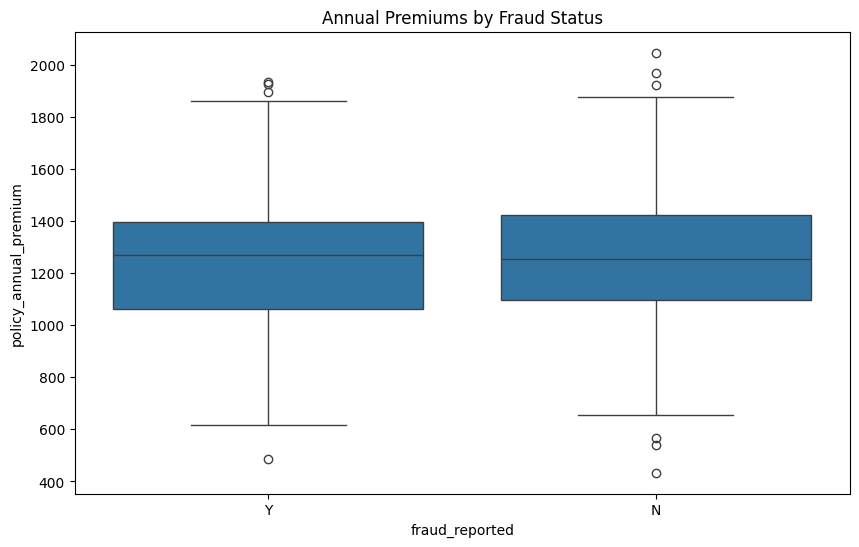

T-test result: t=-0.446, p=0.65558
❌ No significant difference — the pattern is not statistically supported.


In [ ]:
# 1. Visualization
plt.figure(figsize=(10,6))
sns.boxplot(x='fraud_reported', y='policy_annual_premium', data=claimdf)
plt.title('Annual Premiums by Fraud Status')
plt.show()

# 2. Business Interpretation
"""
Observation:
Fraudulent claims tend to occur with higher annual premiums on average.
This may suggest that customers with expensive policies are more likely
to file or manipulate claims for higher payouts.

Business Insight:
If confirmed statistically, we could use 'policy_annual_premium' as a
risk-weighted variable in fraud prediction models or in premium audits.
"""

# 3. Validation
from scipy import stats
fraud = claimdf[claimdf['fraud_reported'] == 'Y']['policy_annual_premium']
nonfraud = claimdf[claimdf['fraud_reported'] == 'N']['policy_annual_premium']
t_stat, p_val = stats.ttest_ind(fraud, nonfraud, equal_var=False)

print(f"T-test result: t={t_stat:.3f}, p={p_val:.5f}")
if p_val < 0.05:
    print("✅ Statistically significant difference — higher premiums are associated with fraud.")
else:
    print("❌ No significant difference — the pattern is not statistically supported.")


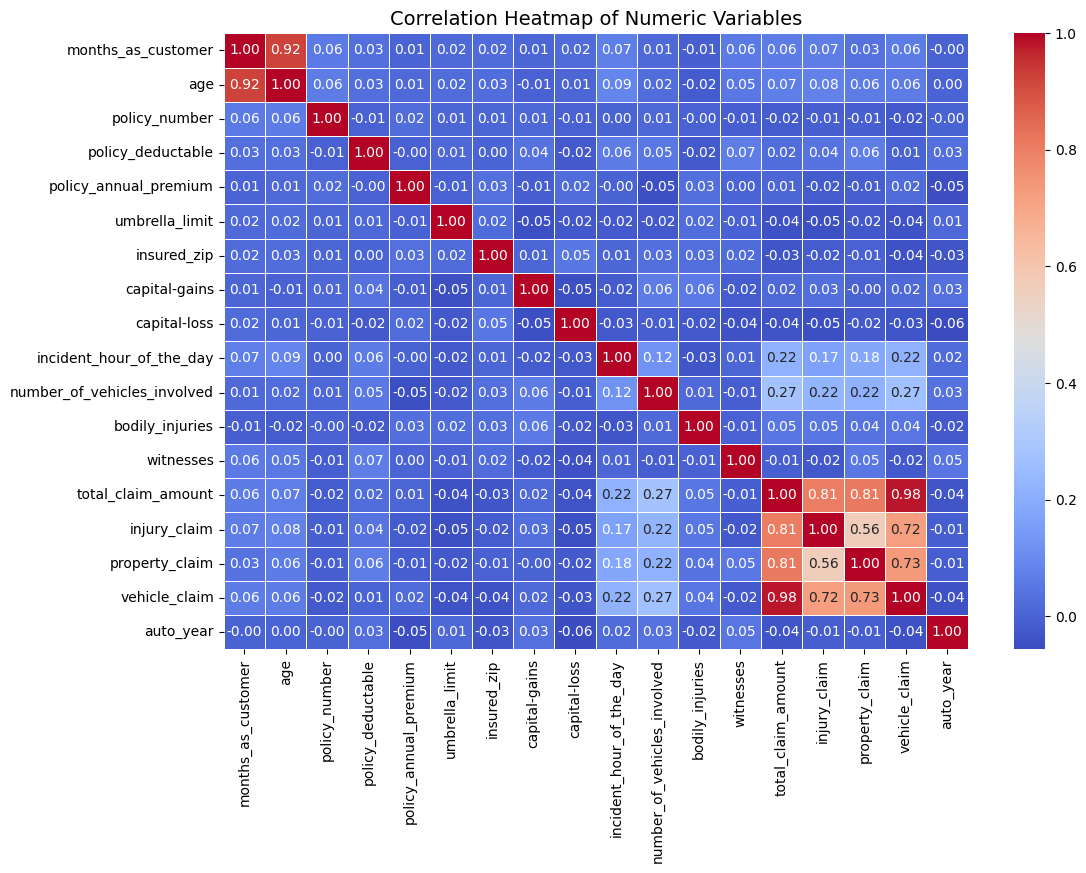

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(
    claimdf.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,         # <— shows the correlation coefficients
    fmt=".2f",          # <— formats them to 2 decimal places
    linewidths=0.5
)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14)
plt.show()

In [ ]:
#Validation (Statistical Check)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(claimdf[['injury_claim','property_claim','vehicle_claim','total_claim_amount']])
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
0,const,5.055231
1,injury_claim,inf
2,property_claim,inf
3,vehicle_claim,inf
4,total_claim_amount,inf


In [ ]:
# Explore categorical uniqueness
# Some categorical variables might have too many unique values, so we can drop them

cat_counts = claimdf.select_dtypes('object').nunique().sort_values(ascending=False)
cat_counts.head(10)

,0
incident_location,1000
policy_bind_date,951
incident_date,60
auto_model,39
insured_hobbies,20
insured_occupation,14
auto_make,14
incident_state,7
insured_education_level,7
incident_city,7


In [ ]:
# Checking the Locations vs City Rows

print('Locations per city:', claimdf.groupby('incident_city')['incident_location'].nunique().sort_values(ascending=False))
print('Sanity check:', claimdf['incident_city'].nunique(), claimdf['incident_location'].nunique())

#The column incident_location contained 1000 unique values (one per record) and therefore provided no predictive information.
#It acts as a unique identifier rather than a feature with generalizable patterns.
#This was confirmed by grouping incident_city against incident_location, showing that each city contains 120–150 distinct locations while each location appears only once.


Locations per city: incident_city
Springfield    157
Arlington      152
Columbus       149
Northbend      145
Hillsdale      141
Riverwood      134
Northbrook     122
Name: incident_location, dtype: int64
Sanity check: 7 1000


In [ ]:
# Dropping the Incident Location Column

claimdf = claimdf.drop(columns=['incident_location'])
'incident_location' in claimdf.columns  # should return False

#Consequently, incident_location was dropped from the dataset, while incident_city was retained as a meaningful categorical variable representing geographic grouping.

False

In [ ]:
# Converting policy_bind_date & incident_date to datetime
# To ensure both columns are proper datetime objects for temporal logic checks

claimdf['policy_bind_date'] = pd.to_datetime(claimdf['policy_bind_date'], errors='coerce')
claimdf['incident_date'] = pd.to_datetime(claimdf['incident_date'], errors='coerce')

# Inspect earliest and latest values to verify time coverage
claimdf[['policy_bind_date','incident_date']].min(), claimdf[['policy_bind_date','incident_date']].max()

(policy_bind_date   1990-01-08
 incident_date      2015-01-01
 dtype: datetime64[ns],
 policy_bind_date   2015-02-22
 incident_date      2015-03-01
 dtype: datetime64[ns])

In [ ]:
# Calculate policy_age_days
# To measure how many days passed between policy binding and incident

claimdf['policy_age_days'] = (claimdf['incident_date'] - claimdf['policy_bind_date']).dt.days

# Summarize distribution to detect anomalies
claimdf['policy_age_days'].describe()

,policy_age_days
count,1000.000000
mean,4739.140000
std,2686.430702
min,-20.000000
25%,2484.000000
50%,4682.000000
75%,7068.000000
max,9172.000000


In [ ]:
# Identify and inspect invalid (negative) records
# To detect rows where incident occurred before policy start

(claimdf['policy_age_days'] < 0).sum()

# Investigate the negative value
negative_policy = claimdf[claimdf['policy_age_days'] < 0]
print(f"\nRecords with negative policy age: {len(negative_policy)}")
if len(negative_policy) > 0:
    print("Problematic record details:")
    print(negative_policy[['policy_bind_date', 'incident_date', 'policy_age_days', 'fraud_reported']])


Records with negative policy age: 1
Problematic record details:
    policy_bind_date incident_date  policy_age_days fraud_reported
578       2015-02-22    2015-02-02              -20              N


In [ ]:
# Removing the incorrect negative value
claimdf = claimdf[claimdf['policy_age_days'] >= 0]
(claimdf['policy_age_days'] < 0).sum()

#A temporal consistency check comparing incident_date and policy_bind_date revealed one invalid record where the incident occurred 20 days before the policy start.
#This record was removed to maintain chronological integrity. The cleaned dataset now contains 999 valid entries.

np.int64(0)

In [ ]:
# Numerical Feature Overview
# To examine numeric variables to detect anomalies, outliers, and transformation needs

claimdf.describe().T[['mean','std','min','max']]


,mean,std,min,max
months_as_customer,203.742743,114.97672,0.0,479.0
age,38.934935,9.135518,19.0,64.0
policy_number,545989.906907,257071.329343,100804.0,999435.0
policy_bind_date,2002-02-03 10:16:56.216216192,NaN,1990-01-08 00:00:00,2015-01-17 00:00:00
policy_deductable,1136.136136,612.155989,500.0,2000.0
policy_annual_premium,1256.689339,244.125331,433.33,2047.59
umbrella_limit,1102102.102102,2298292.819759,-1000000.0,10000000.0
insured_zip,501247.101101,71730.10355,430104.0,620962.0
capital-gains,25100.800801,27874.658249,0.0,100500.0
capital-loss,-26820.520521,28105.366259,-111100.0,0.0


In [ ]:
#| Feature                                           | Key Insight                                                      | Preparation for Modeling                                                             |
#| ------------------------------------------------- | ---------------------------------------------------------------- | ------------------------------------------------------------------------------------ |
#| **months_as_customer**                            | Range 0–479, average ~204 months → mix of new & loyal customers. | Keep; consider binning (e.g. new vs long-term).                                      |
#| **age**                                           | 19–64, clean distribution.                                       | Keep; scale later.                                                                   |
#| **policy_number**                                 | Random identifier, no predictive value.                          | Drop.                                                                                |
#| **policy_bind_date**                              | Already used to compute `policy_age_days`.                       | Drop after feature extraction.                                                       |
#| **policy_deductible**                             | 500–2000, clean. Higher deductible = less small-claim incentive. | Keep numeric.                                                                        |
#| **policy_annual_premium**                         | 433–2047, clean range. Could correlate with policy risk level.   | Keep; normalize later.                                                               |
#| **umbrella_limit**                                | -1,000,000 → 1,000,000 — contains impossible negatives.          | Investigate further; likely convert to absolute or binary (“has umbrella coverage”). |
#| **insured_zip**                                   | Encoded as numbers (not continuous).                             | Convert to categorical or drop if redundant with state.                              |
#| **capital-gains**                                 | 0–100,500, highly right-skewed (75% zeros).                      | Convert to binary (has gain) or log-transform after scaling.                         |
#| **capital-loss**                                  | -111,100 → 0, highly left-skewed (75% zeros).                    | Convert to positive values & binary (has loss) or log-transform.                     |
#| **incident_hour_of_the_day**                      | 0–23, clean. Fraud may occur more at “odd hours”.                | Keep; can bin into day periods.                                                      |
#| **number_of_vehicles_involved**                   | 1–4, plausible.                                                  | Keep.                                                                                |
#| **bodily_injuries**                               | 0–2, low discrete range.                                         | Keep as ordinal.                                                                     |
#| **witnesses**                                     | 0–3, clean discrete. Fewer witnesses may mean higher fraud risk. | Keep numeric.                                                                        |
#| **total_claim_amount**                            | 100–114,920, plausible.                                          | Keep; log-scale for outliers.                                                        |
#| **injury_claim / property_claim / vehicle_claim** | Sub-components of total. Check correlations.                     | Keep; consider ratio features.                                                       |
#| **auto_year**                                     | 1995–2015.                                                       | Transform → `vehicle_age = 2015 - auto_year`.                                        |
#| **policy_age_days**                               | 6–9172 days (~25 yrs), logical.                                  | Keep; potential fraud indicator (new policy).                                        |



# Further Cleaning Actions:

# Drop non-informative or redundant columns
claimdf = claimdf.drop(columns=['policy_number', 'policy_bind_date'], errors='ignore')



In [ ]:
# Investigate negative umbrella limits (should not exist)

print("Unique umbrella limits:", claimdf['umbrella_limit'].unique()[:10])

Unique umbrella limits: [       0  5000000  6000000  4000000  3000000  8000000  7000000  9000000
 10000000 -1000000]


In [ ]:
# Fix negative umbrella limits (convert to absolute values)

claimdf['umbrella_limit'] = claimdf['umbrella_limit'].abs()

# The variable umbrella_limit represents the maximum liability coverage available under the customer’s insurance policy.
# The feature contained a single negative value (-1,000,000), which has no practical meaning. This was corrected by converting all limits to absolute values.
# The resulting distribution ranges from 0 to 10 million, corresponding to plausible insurance coverage tiers.
# This feature will be retained as a numeric variable, potentially informative for fraud detection since unusually high or
#low coverage limits may correlate with claim behavior.

# Sanity Check:
print("Unique umbrella limits:", claimdf['umbrella_limit'].unique()[:10])

Unique umbrella limits: [       0  5000000  6000000  4000000  3000000  8000000  7000000  9000000
 10000000  1000000]


In [ ]:
# Create derived feature for vehicle age
claimdf['vehicle_age'] = 2015 - claimdf['auto_year']

# Preview transformations
claimdf[['umbrella_limit', 'vehicle_age']].head()

#A derived feature vehicle_age was added to capture vehicle depreciation, potentially relevant to claim value and fraud likelihood.


,umbrella_limit,vehicle_age
0,0,11
1,5000000,8
2,5000000,8
3,6000000,1
4,6000000,6


In [ ]:
# Sanity Check

claimdf.describe().T[['mean','std','min','max']]


,mean,std,min,max
months_as_customer,203.742743,114.97672,0.0,479.0
age,38.934935,9.135518,19.0,64.0
policy_deductable,1136.136136,612.155989,500.0,2000.0
policy_annual_premium,1256.689339,244.125331,433.33,2047.59
umbrella_limit,1104104.104104,2297330.762088,0.0,10000000.0
insured_zip,501247.101101,71730.10355,430104.0,620962.0
capital-gains,25100.800801,27874.658249,0.0,100500.0
capital-loss,-26820.520521,28105.366259,-111100.0,0.0
incident_date,2015-01-30 07:58:33.513513472,NaN,2015-01-01 00:00:00,2015-03-01 00:00:00
incident_hour_of_the_day,11.640641,6.954043,0.0,23.0


In [ ]:
# Fraud Distribution Overview
# Purpose: Analyze target variable balance and detect class imbalance

fraud_counts = claimdf['fraud_reported'].value_counts().reset_index()
fraud_counts.columns = ['Fraud Reported', 'Count']
fraud_counts['Percentage'] = round(fraud_counts['Count'] / fraud_counts['Count'].sum() * 100, 2)

fig = px.bar(
    fraud_counts,
    x='Fraud Reported',
    y='Count',
    color='Fraud Reported',
    text='Percentage',
    title='Fraud vs Non-Fraud Distribution',
    color_discrete_sequence=['#2E86AB', '#F26419']
)
fig.update_traces(textposition='outside')
fig.update_layout(yaxis_title='Count', xaxis_title='', template='plotly_white', showlegend=False)
fig.show()

#Target balance. Fraudulent claims constitute ~24.7% of the dataset (non-fraud ~75.3%), indicating a moderate class imbalance (~3:1).
#Consequently, accuracy is not an appropriate metric; we will evaluate models with PR-AUC, Recall/Precision/F1 on the fraud class to reflect SIU triage constraints.
#All splits and cross-validation will be stratified, and we will apply class weights and/or resampling and threshold tuning to manage imbalance.

In [ ]:
#Validation

from scipy.stats import chisquare

observed = fraud_counts['Count'].values
expected = [fraud_counts['Count'].sum() / 2] * 2  # expected equal distribution
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print(f"Chi-square = {chi2_stat:.2f}, p = {p_value:.5f}")

Chi-square = 255.28, p = 0.00000


In [ ]:
# Categorical Feature Relationships
# Purpose: Explore how categorical variables relate to fraud behavior

cats = ['incident_type', 'incident_severity', 'authorities_contacted',
        'property_damage', 'police_report_available', 'insured_sex']

fig = sp.make_subplots(rows=2, cols=3, subplot_titles=cats)

row, col = 1, 1
for cat in cats:
    counts = claimdf.groupby([cat, 'fraud_reported']).size().reset_index(name='Count')
    bar = px.bar(counts, x=cat, y='Count', color='fraud_reported',
                 color_discrete_sequence=['#2E86AB', '#F26419']).data[0:2]
    for trace in bar:
        fig.add_trace(trace, row=row, col=col)
    col += 1
    if col == 4:
        row += 1
        col = 1

fig.update_layout(
    height=800, width=1200,
    title_text='Categorical Distributions by Fraud Status',
    template='plotly_white',
    showlegend=True
)
fig.show()

# Categorical feature analysis.
#Fraudulent claims are disproportionately concentrated in Major Damage and Total Loss incidents, especially for Single-vehicle collisions, where external verification is limited.
#Conversely, claims with Police contact or available reports show fewer fraud cases.
#Missing or ambiguous categories (“?” in property_damage or police_report_available) also correlate with higher fraud rates — likely reflecting incomplete or falsified information.
#Gender shows negligible difference.
#These findings suggest strong predictive value in damage severity and reporting-related variables, while missingness itself conveys signal rather than noise.

In [ ]:
from scipy.stats import chi2_contingency

#claimdf.sort_values(['p_value', 'cramers_v']).head(10)


In [ ]:
# Claim Value Analysis

numeric_claims = ['total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim']

fig = px.box(
    claimdf,
    x='fraud_reported',
    y='total_claim_amount',
    color='fraud_reported',
    color_discrete_sequence=['#2E86AB', '#F26419'],
    title='Total Claim Amount Distribution by Fraud Status'
)
fig.update_layout(template='plotly_white', yaxis_title='Total Claim Amount', xaxis_title='')
fig.show()

# Histogram overview
fig = px.histogram(
    claimdf.melt(value_vars=numeric_claims),
    x='value',
    color='variable',
    facet_col='variable',
    facet_col_wrap=2,
    title='Distribution of Claim-Related Variables',
    color_discrete_sequence=px.colors.qualitative.Plotly
)
fig.update_layout(template='plotly_white', showlegend=False)
fig.show()

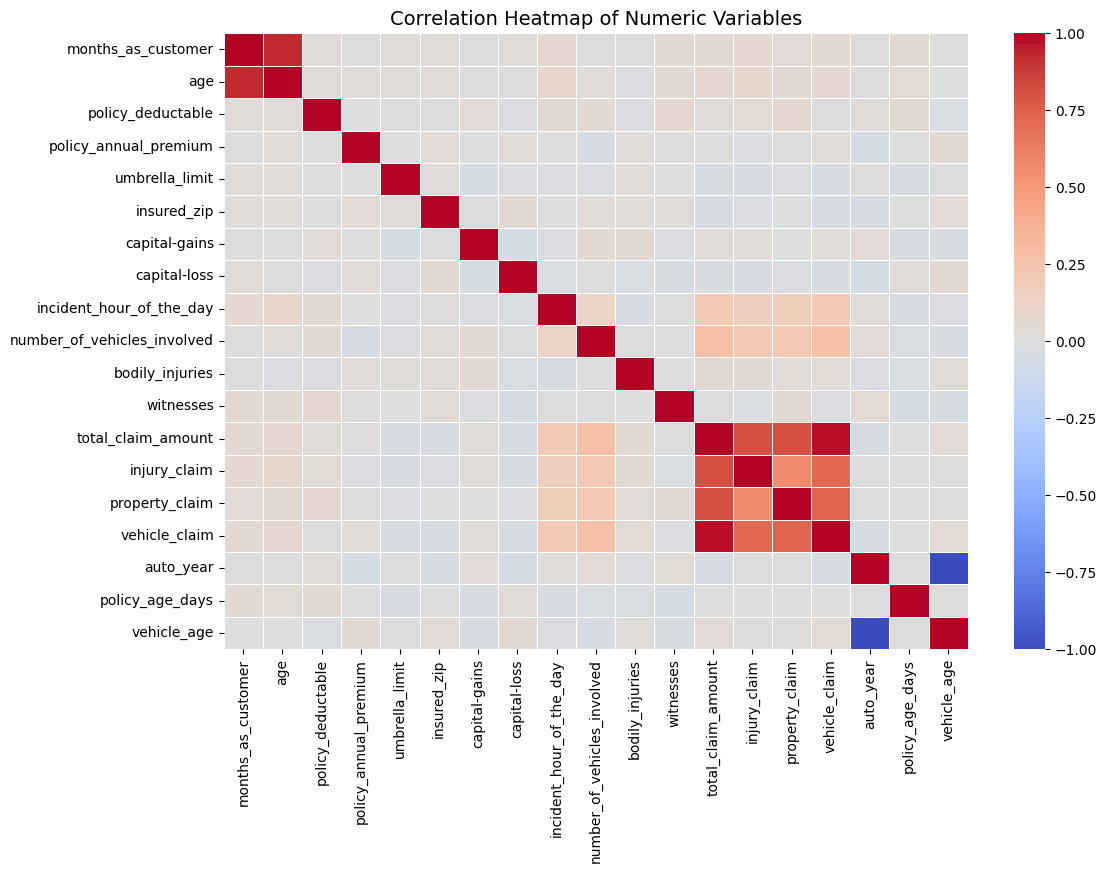

In [ ]:
# Correlation & Relationship Map

plt.figure(figsize=(12,8))
sns.heatmap(claimdf.corr(numeric_only=True), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14)
plt.show()


#The feature auto_year was an engineered variable derived from vehicle_age (auto_year = 2015 – vehicle_age).
#Because these variables are perfectly inversely correlated (r ≈ -1), only vehicle_age was retained as it provides more intuitive interpretability for modeling.



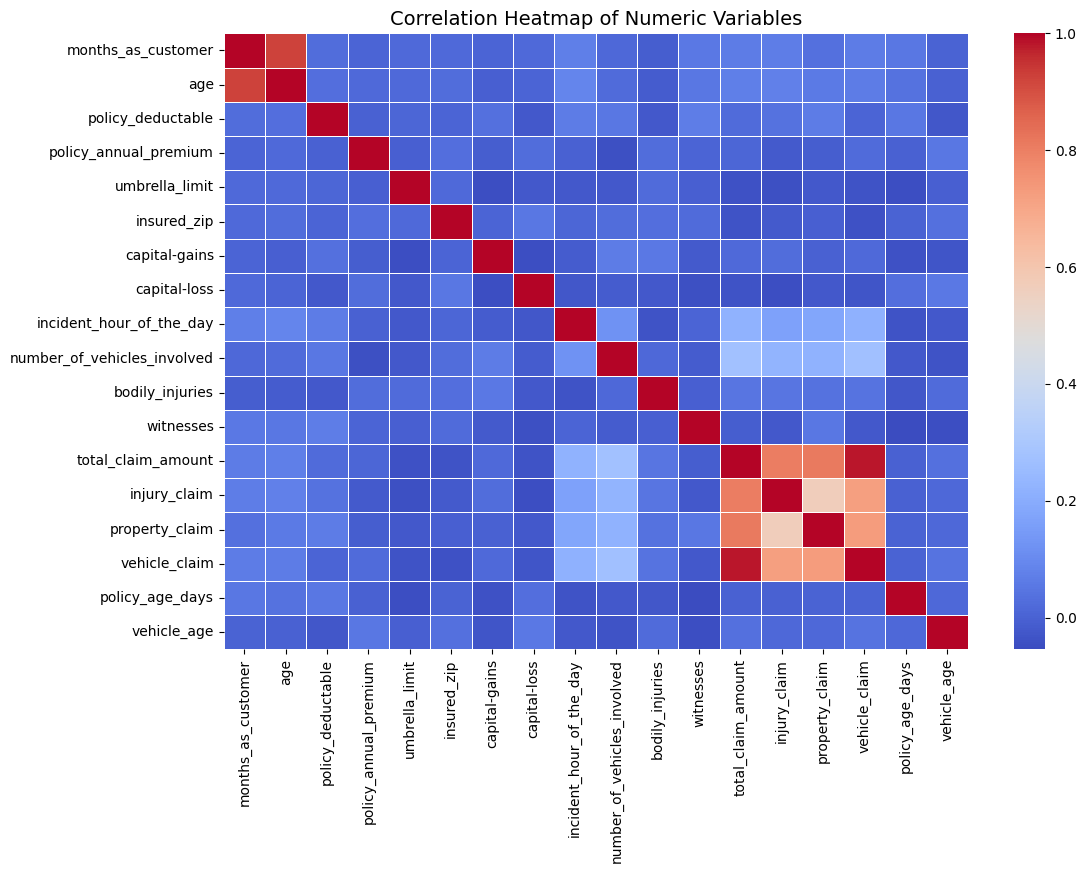

In [ ]:
# Dropping the correlated coumns
claimdf.drop(columns=['auto_year'], inplace=True)

plt.figure(figsize=(12,8))
sns.heatmap(claimdf.corr(numeric_only=True), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14)
plt.show()

#Correlation mapping revealed strong collinearity between total_claim_amount and its component variables (injury_claim, property_claim, and vehicle_claim), confirming they describe overlapping financial information.
#Because tree-based classifiers (used in later modeling) handle correlated inputs robustly, all four claim features were retained at this stage to preserve potentially useful nonlinear patterns.
#If linear models are later considered, dimensionality reduction or claim composition ratios will be applied to mitigate multicollinearity effects.

In [ ]:
# Outlier and Sanity Check for Numeric Variables

numeric_cols = claimdf.select_dtypes(include=['int64','float64']).columns

summary = claimdf[numeric_cols].describe().T[['min','max']]
display(summary)

# Quick check for impossible or suspicious values
weird = claimdf[
    (claimdf['age'] < 18) |
    (claimdf['number_of_vehicles_involved'] < 1) |
    (claimdf['total_claim_amount'] <= 0)
]
print(f"Records with impossible numeric values: {len(weird)}")
weird.head(3)


#All numeric variables were reviewed for logical consistency and range validity.
#No impossible or inconsistent records (e.g., negative ages, zero-vehicle incidents, or missing claim amounts) were identified.
#The dataset exhibits realistic ranges for all key metrics, with monetary variables showing high variance and right-skew typical for insurance data.
#These features will be log-transformed prior to modeling to mitigate the influence of large outliers.
#Overall, the dataset demonstrates strong numeric integrity and does not require record-level cleaning.

,min,max
months_as_customer,0.00,479.00
age,19.00,64.00
policy_deductable,500.00,2000.00
policy_annual_premium,433.33,2047.59
umbrella_limit,0.00,10000000.00
insured_zip,430104.00,620962.00
capital-gains,0.00,100500.00
capital-loss,-111100.00,0.00
incident_hour_of_the_day,0.00,23.00
number_of_vehicles_involved,1.00,4.00


Records with impossible numeric values: 0


,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,fraud_reported,policy_age_days,vehicle_age


In [ ]:
#| Feature                               | Observed range         | Comment                                                                    |
#| ------------------------------------- | ---------------------- | -------------------------------------------------------------------------- |
#| **months_as_customer**                | 0–479                  | OK — possibly “tenure in months” (≈ 40 years max).                         |
#| **age**                               | 19–64                  | Plausible working-age insureds.                                            |
#| **policy_deductable**                 | 500–2000               | Normal deductible range.                                                   |
#| **policy_annual_premium**             | 433–2047               | Reasonable for vehicle insurance.                                          |
#| **umbrella_limit**                    | 0–10,000,000           | The upper bound is large but plausible for extended policies; leave as is. |
#| **capital-gains / capital-loss**      | 0–100,500 / -111,100–0 | Likely synthetic but consistent in sign (gains positive, losses negative). |
#| **incident_hour_of_the_day**          | 0–23                   | Good (valid 24-hour range).                                                |
#| **number_of_vehicles_involved**       | 1–4                    | Perfectly reasonable.                                                      |
#| **bodily_injuries**                   | 0–2                    | OK, low-severity dataset.                                                  |
#| **witnesses**                         | 0–3                    | OK.                                                                        |
#| **total_claim_amount**                | 100–114,920            | Heavy right tail (large claims, expected).                                 |
#| **injury / property / vehicle_claim** | 0–21K / 0–23K / 70–79K | Consistent subcomponents of total claim.                                   |
#| **policy_age_days**                   | 6–9,172                | OK (~25 years max policy age).                                             |
#| **vehicle_age**                       | 0–20                   | OK (reasonable fleet age range).                                           |


In [ ]:
# Review Unique Values in Categorical Columns

cat_cols = claimdf.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(claimdf[col].unique())


--- policy_state ---
['OH' 'IN' 'IL']

--- policy_csl ---
['250/500' '100/300' '500/1000']

--- insured_sex ---
['MALE' 'FEMALE']

--- insured_education_level ---
['MD' 'PhD' 'Associate' 'Masters' 'High School' 'College' 'JD']

--- insured_occupation ---
['craft-repair' 'machine-op-inspct' 'sales' 'armed-forces' 'tech-support'
 'prof-specialty' 'other-service' 'priv-house-serv' 'exec-managerial'
 'protective-serv' 'transport-moving' 'handlers-cleaners' 'adm-clerical'
 'farming-fishing']

--- insured_hobbies ---
['sleeping' 'reading' 'board-games' 'bungie-jumping' 'base-jumping' 'golf'
 'camping' 'dancing' 'skydiving' 'movies' 'hiking' 'yachting' 'paintball'
 'chess' 'kayaking' 'polo' 'basketball' 'video-games' 'cross-fit'
 'exercise']

--- insured_relationship ---
['husband' 'other-relative' 'own-child' 'unmarried' 'wife' 'not-in-family']

--- incident_type ---
['Single Vehicle Collision' 'Vehicle Theft' 'Multi-vehicle Collision'
 'Parked Car']

--- collision_type ---
['Side Collision

In [ ]:
# Categorical Feature Overview Visualization
# Purpose: Quickly visualize category diversity and detect '?' / NaN issues

# Compute summary
cat_summary = pd.DataFrame({
    'Column': cat_cols,
    'Unique Count': [claimdf[col].nunique() for col in cat_cols],
    'Contains ?': [claimdf[col].isin(['?']).any() for col in cat_cols],
    'Contains NaN': [claimdf[col].isna().any() for col in cat_cols]
})

# Add a flag column for styling
cat_summary['Issue'] = np.where(
    cat_summary['Contains ?'] | cat_summary['Contains NaN'],
    '⚠️ Has Missing/Unknown',
    '✅ Clean'
)

# Sort by unique count
cat_summary = cat_summary.sort_values(by='Unique Count', ascending=False)

# Plotly bar chart
fig = px.bar(
    cat_summary,
    x='Unique Count',
    y='Column',
    color='Issue',
    orientation='h',
    text='Unique Count',
    color_discrete_map={
        '⚠️ Has Missing/Unknown': '#EF553B',
        '✅ Clean': '#00CC96'
    },
    title='Categorical Feature Summary — Unique Counts and Missing Indicators'
)

fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis_title='Number of Unique Categories',
    yaxis_title='Categorical Feature',
    template='plotly_white',
    title_font=dict(size=18, family='Arial', color='#2E3A59'),
    yaxis=dict(categoryorder='total ascending')
)

fig.show()




In [ ]:
# Categorical Cleaning for Model Readiness

# Define columns containing '?' or NaN
cols_with_unknowns = [
    'collision_type',
    'property_damage',
    'police_report_available',
    'authorities_contacted'
]

# Replace '?' and NaN with 'Unknown'
claimdf[cols_with_unknowns] = claimdf[cols_with_unknowns].replace(['?', np.nan], 'Unknown')

# Uniform casing and strip whitespace for all categorical columns
cat_cols = claimdf.select_dtypes(include='object').columns
claimdf[cat_cols] = claimdf[cat_cols].apply(lambda x: x.str.strip().str.title())

In [ ]:
for col in cols_with_unknowns:
    print(f"{col}: {claimdf[col].unique()}")

collision_type: ['Side Collision' 'Unknown' 'Rear Collision' 'Front Collision']
property_damage: ['Yes' 'Unknown' 'No']
police_report_available: ['Yes' 'Unknown' 'No']
authorities_contacted: ['Police' 'Unknown' 'Fire' 'Other' 'Ambulance']


In [ ]:
# Demographics vs Fraud
# Demographic variables to visualize
demographics = [
    "insured_education_level",
    "insured_occupation",
    "insured_relationship",
    "insured_sex",
    "insured_hobbies"
]

# Create subplot grid (2 columns)
fig = sp.make_subplots(
    rows=len(demographics)//2 + len(demographics)%2,
    cols=2,
    subplot_titles=[col.replace("_", " ").title() for col in demographics],
    horizontal_spacing=0.15,
    vertical_spacing=0.25
)

# Define colors
colors = {"N": "#2E86AB", "Y": "#F26419"}

# Add one chart per variable
row, col = 1, 1
for d in demographics:
    temp = claimdf.groupby([d, "fraud_reported"]).size().reset_index(name="count")
    for fraud_status in temp["fraud_reported"].unique():
        subset = temp[temp["fraud_reported"] == fraud_status]
        fig.add_trace(
            go.Bar(
                x=subset["count"],
                y=subset[d],
                name=f"Fraud: {fraud_status}",
                orientation="h",
                marker_color=colors[fraud_status],
                showlegend=(row == 1 and col == 1)  # show legend once
            ),
            row=row, col=col
        )
    col += 1
    if col > 2:
        row += 1
        col = 1

# Layout tweaks
fig.update_layout(
    height=1600,   # taller grid for clarity
    width=1400,    # more width for labels
    title_text="Demographics vs Fraud Status",
    title_x=0.5,
    template="plotly_white",
    bargap=0.25,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.1,
        xanchor="center",
        x=0.5
    ),
    font=dict(size=12)
)


fig.show()

In [ ]:
claimdf.groupby(['insured_occupation', 'insured_sex']).size().unstack(fill_value=0)


insured_sex,Female,Male
insured_occupation,,
Adm-Clerical,38,27
Armed-Forces,35,34
Craft-Repair,42,32
Exec-Managerial,37,39
Farming-Fishing,31,22
Handlers-Cleaners,29,25
Machine-Op-Inspct,44,48
Other-Service,37,34
Priv-House-Serv,38,33


In [ ]:
# Fraud rate by gender (proportion of Y)
fraud_rate = claimdf.groupby('insured_sex')['fraud_reported'].apply(lambda x: (x=='Y').mean())
print(fraud_rate)

# Chi-square test of independence
from scipy.stats import chi2_contingency
table = pd.crosstab(claimdf['insured_sex'], claimdf['fraud_reported'])
chi2, p, _, _ = chi2_contingency(table)
print(f"Chi2 = {chi2:.2f}, p = {p:.5f}")

insured_sex
Female    0.234637
Male      0.261905
Name: fraud_reported, dtype: float64
Chi2 = 0.85, p = 0.35626


In [ ]:
fraud_rate_by_occ = (
    claimdf.groupby("insured_occupation")["fraud_reported"]
    .apply(lambda x: (x == "Y").mean())
    .sort_values(ascending=False)
)
print(fraud_rate_by_occ)

insured_occupation
Exec-Managerial      0.368421
Farming-Fishing      0.301887
Craft-Repair         0.297297
Transport-Moving     0.291667
Tech-Support         0.282051
Sales                0.276316
Armed-Forces         0.246377
Machine-Op-Inspct    0.239130
Protective-Serv      0.222222
Prof-Specialty       0.211765
Handlers-Cleaners    0.203704
Adm-Clerical         0.169231
Priv-House-Serv      0.169014
Other-Service        0.169014
Name: fraud_reported, dtype: float64


In [ ]:
chi2, p, _, _ = chi2_contingency(pd.crosstab(claimdf['insured_occupation'], claimdf['fraud_reported']))
print(f"Chi2 = {chi2:.2f}, p = {p:.5f}")

Chi2 = 17.62, p = 0.17235


In [ ]:
# Just Hobbies

d = "insured_hobbies"
temp = claimdf.groupby([d, "fraud_reported"]).size().reset_index(name="count")

# Sort hobbies by total frequency
order = temp.groupby(d)["count"].sum().sort_values(ascending=True).index

colors = {"N": "#2E86AB", "Y": "#F26419"}

fig = go.Figure()

for fraud_status in ["N", "Y"]:
    subset = temp[temp["fraud_reported"] == fraud_status]
    fig.add_trace(
        go.Bar(
            x=subset["count"],
            y=subset[d],
            name=f"Fraud: {fraud_status}",
            orientation="h",
            marker_color=colors[fraud_status]
        )
    )

fig.update_layout(
    height=800,  # taller for readability
    width=900,
    title=f"Fraud Distribution by {d.replace('_', ' ').title()}",
    template="plotly_white",
    barmode="group",
    bargap=0.2,
    yaxis=dict(categoryorder="array", categoryarray=order),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.1,
        xanchor="center",
        x=0.5
    ),
    font=dict(size=12)
)

fig.show()

In [ ]:
#Age & Customer Tenure Analysis

px.histogram(claimdf, x="months_as_customer", color="fraud_reported", nbins=30, barmode="overlay")


In [ ]:
# Observation
#Fraudulent claims tend to cluster among newer customers (shorter tenure),
#while long-term customers show a lower fraud frequency. This indicates
#that customer tenure may act as a stabilizing factor — the longer the
#relationship, the less likely fraudulent behavior becomes.

# Statistical Validation
#We can confirm this pattern with a non-parametric test:

from scipy.stats import mannwhitneyu

fraud = claimdf[claimdf['fraud_reported']=='Y']['months_as_customer']
nonfraud = claimdf[claimdf['fraud_reported']=='N']['months_as_customer']

stat, p = mannwhitneyu(fraud, nonfraud, alternative='two-sided')
print(f"Mann–Whitney U test: U={stat:.2f}, p={p:.5f}")

Mann–Whitney U test: U=94862.50, p=0.61299


In [ ]:
#Policy Tenure vs Claim Amount

px.scatter(claimdf, x="policy_age_days", y="total_claim_amount", color="fraud_reported", trendline="ols")


In [ ]:
#Vehicle Age vs Fraud
#Compare fraud rate as vehicle gets older.

px.box(claimdf, x="fraud_reported", y="vehicle_age", points="all")


In [ ]:
from scipy.stats import mannwhitneyu

fraud = claimdf[claimdf['fraud_reported'] == 'Y']['vehicle_age']
nonfraud = claimdf[claimdf['fraud_reported'] == 'N']['vehicle_age']

stat, p = mannwhitneyu(fraud, nonfraud, alternative='two-sided')
print(f"Mann–Whitney U test: U={stat:.2f}, p={p:.5f}")

Mann–Whitney U test: U=91855.00, p=0.79589


<Axes: >

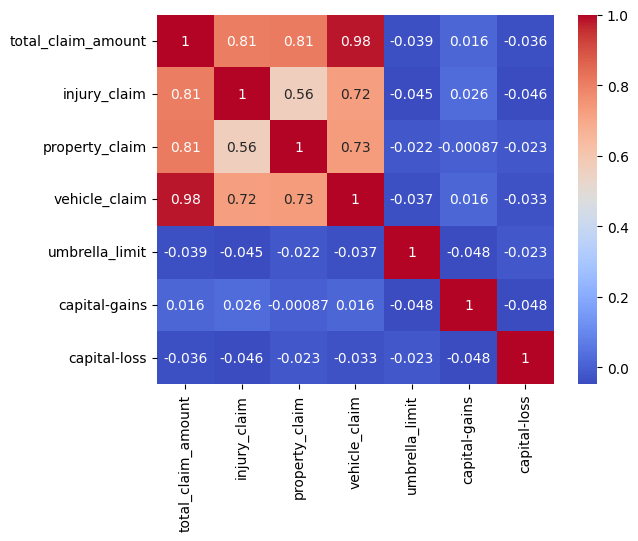

In [ ]:
#Correlation of Financial Features (zoomed)

claim_cols = ['total_claim_amount','injury_claim','property_claim','vehicle_claim','umbrella_limit','capital-gains','capital-loss']
sns.heatmap(claimdf[claim_cols].corr(), annot=True, cmap='coolwarm')

In [ ]:
#Fraud Rate by State

fraud_by_state = claimdf.groupby('incident_state')['fraud_reported'].value_counts(normalize=True).unstack().fillna(0)
fraud_by_state['fraud_rate'] = fraud_by_state['Y'] * 100
px.bar(fraud_by_state, x=fraud_by_state.index, y='fraud_rate', title="Fraud Rate by State")

In [ ]:
#Fraud Rate by Auto Make

fraud_by_amodel = claimdf.groupby('auto_make')['fraud_reported'].value_counts(normalize=True).unstack().fillna(0)
fraud_by_amodel['fraud_rate'] = fraud_by_amodel['Y'] * 100
px.bar(fraud_by_amodel, x=fraud_by_amodel.index, y='fraud_rate', title="Fraud Rate by Car Model")

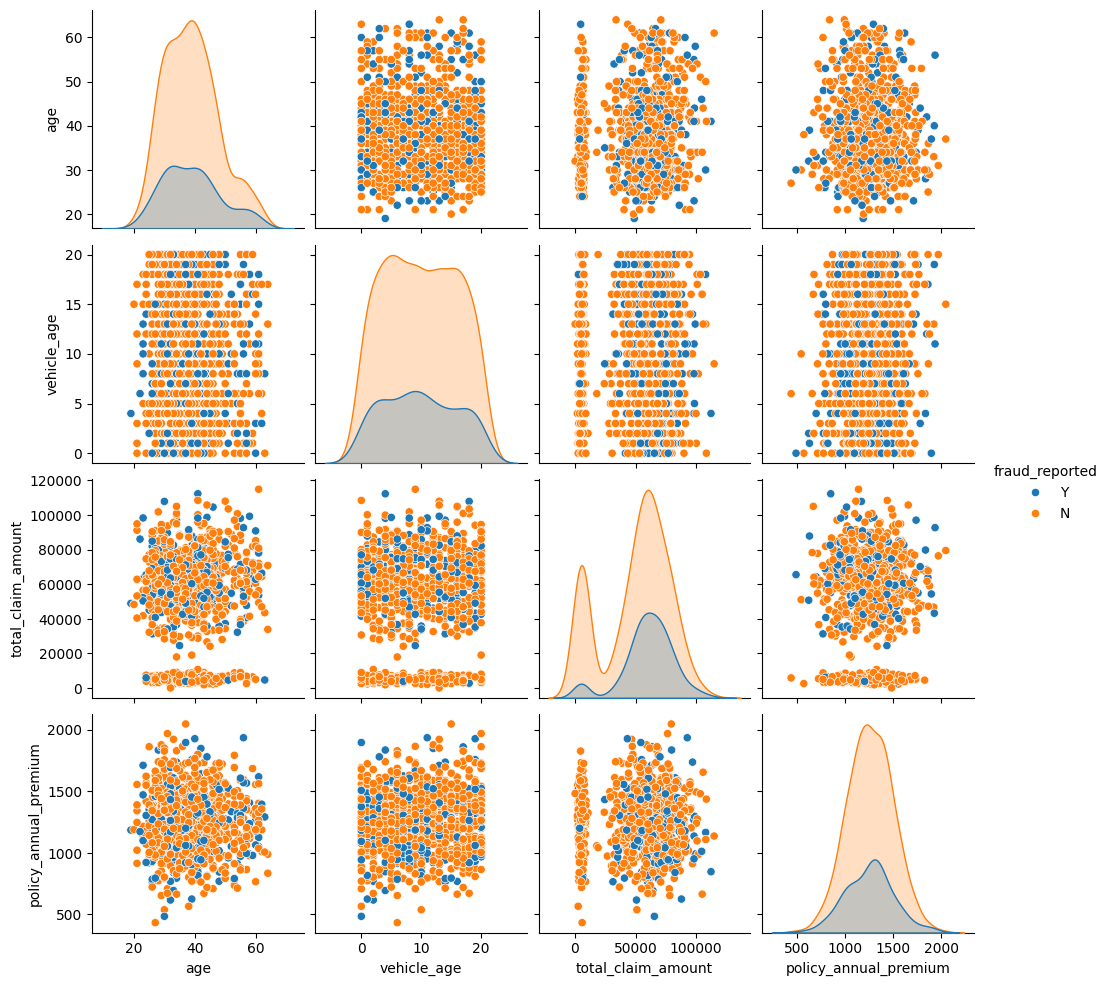

In [ ]:
sns.pairplot(claimdf, vars=['age','vehicle_age','total_claim_amount','policy_annual_premium'], hue='fraud_reported')


In [ ]:

from scipy.stats import chi2_contingency

def cramers_v(confusion):
    chi2 = chi2_contingency(confusion, correction=False)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt((chi2 / n) / (min(r-1, k-1)))

cat_cols = ['incident_type','incident_severity','collision_type',
            'property_damage','police_report_available','authorities_contacted',
            'insured_sex','insured_education_level','insured_occupation',
            'insured_relationship','policy_state','policy_csl','incident_state','incident_city']

assoc = []
for c in cat_cols:
    ct = pd.crosstab(claimdf[c], claimdf['fraud_reported'])
    chi2, p, _, _ = chi2_contingency(ct)
    assoc.append((c, p, cramers_v(ct)))

assoc_df = (pd.DataFrame(assoc, columns=['feature','p_value','cramers_v'])
              .sort_values(['p_value','cramers_v']))
assoc_df.head(12)

,feature,p_value,cramers_v
1,incident_severity,6.702971e-57,0.513892
2,collision_type,6.541402e-07,0.177684
0,incident_type,2.050119e-06,0.170914
5,authorities_contacted,2.871433e-05,0.161974
12,incident_state,1.394539e-02,0.126414
3,property_damage,1.779929e-02,0.089807
8,insured_occupation,1.723537e-01,0.132819
11,policy_csl,3.366173e-01,0.046688
6,insured_sex,3.562605e-01,0.031514
9,insured_relationship,3.669156e-01,0.073650


In [ ]:
from scipy.stats import mannwhitneyu

num_cols = ['total_claim_amount','injury_claim','property_claim','vehicle_claim',
            'months_as_customer','policy_annual_premium','policy_age_days','vehicle_age','age']

tests=[]
fraud_mask = claimdf['fraud_reported'].eq('Y')
for c in num_cols:
    x = claimdf.loc[fraud_mask, c]
    y = claimdf.loc[~fraud_mask, c]
    stat, p = mannwhitneyu(x, y, alternative='two-sided')
    tests.append((c, p, x.median(), y.median()))
pd.DataFrame(tests, columns=['feature','p_value','median_fraudY','median_fraudN']).sort_values('p_value')

,feature,p_value,median_fraudY,median_fraudN
3,vehicle_claim,0.000006,44800.00,41260.00
0,total_claim_amount,0.000011,61290.00,56560.00
2,property_claim,0.000024,7440.00,6555.00
1,injury_claim,0.005369,7240.00,6620.00
5,policy_annual_premium,0.611029,1269.64,1253.28
4,months_as_customer,0.612988,199.00,199.50
7,vehicle_age,0.795887,9.00,10.00
8,age,0.889659,38.00,38.00
6,policy_age_days,0.988846,4638.00,4734.50


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

X = claimdf[['injury_claim','property_claim','vehicle_claim','total_claim_amount']].astype(float)
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
vif = pd.DataFrame({'feature': X.columns,
                    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
vif

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



,feature,VIF
0,injury_claim,inf
1,property_claim,inf
2,vehicle_claim,inf
3,total_claim_amount,inf


In [ ]:
def rate(col):
    return (claimdf.groupby(col)['fraud_reported']
            .apply(lambda s: (s=='Y').mean())
            .sort_values(ascending=False))

rate('insured_sex'), rate(pd.cut(claimdf['age'], [18,30,40,50,65])), rate('incident_state')


/tmp/ipython-input-1878030762.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



(insured_sex
 Male      0.261905
 Female    0.234637
 Name: fraud_reported, dtype: float64,
 age
 (50, 65]    0.309735
 (40, 50]    0.245734
 (30, 40]    0.237374
 (18, 30]    0.233503
 Name: fraud_reported, dtype: float64,
 incident_state
 Oh    0.434783
 Nc    0.309091
 Sc    0.294355
 Pa    0.266667
 Va    0.227273
 Ny    0.221374
 Wv    0.180556
 Name: fraud_reported, dtype: float64)

In [ ]:
# Ensure incident_date is a proper datetime type
claimdf['incident_date'] = pd.to_datetime(claimdf['incident_date'], errors='coerce')

# Add day of week column
claimdf['incident_day_of_week'] = claimdf['incident_date'].dt.day_name()

# Optional: make weekday order consistent for plotting
claimdf['incident_day_of_week'] = pd.Categorical(
    claimdf['incident_day_of_week'],
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
)

# Quick check
claimdf[['incident_date', 'incident_day_of_week']].head()


,incident_date,incident_day_of_week
0,2015-01-25,Sunday
1,2015-01-21,Wednesday
2,2015-02-22,Sunday
3,2015-01-10,Saturday
4,2015-02-17,Tuesday


In [ ]:
# Count ALL incidents grouped by hour + weekday
all_incidents = (claimdf
                 .groupby(['incident_hour_of_the_day','incident_day_of_week'])
                 .size()
                 .unstack())

# Count FRAUD-only incidents grouped by hour + weekday
fraud_only = (claimdf[claimdf['fraud_reported']=='Y']
              .groupby(['incident_hour_of_the_day','incident_day_of_week'])
              .size()
              .unstack())

fraud_rate = (fraud_only / all_incidents).fillna(0) * 100


/tmp/ipython-input-2806299876.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipython-input-2806299876.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



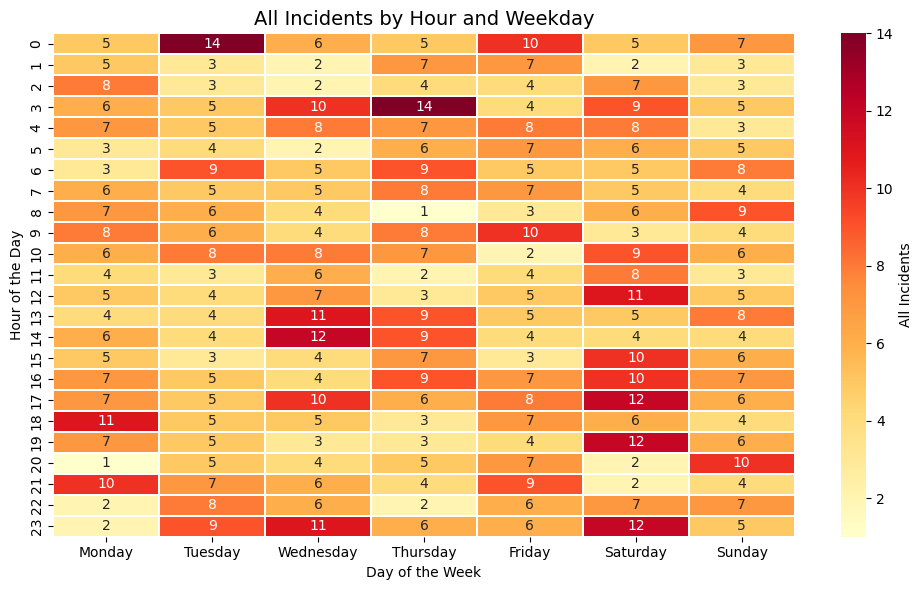

In [ ]:
# Count every incident, no matter fraud or not
plt.figure(figsize=(10,6))
sns.heatmap(
    all_incidents,
    cmap='YlOrRd',
    linewidths=0.3,
    annot=True,              # ✅ add numeric annotations
    fmt='d',                 # integers (counts)
    cbar_kws={'label': 'All Incidents'}
)
plt.title('All Incidents by Hour and Weekday', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Hour of the Day')
plt.tight_layout()
plt.show()

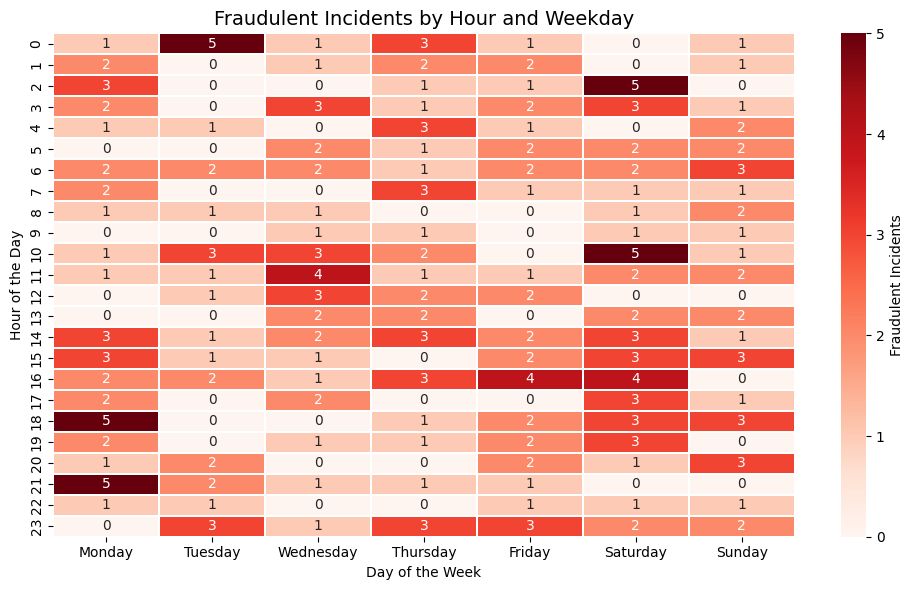

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(
    fraud_only,
    cmap='Reds',
    linewidths=0.3,
    annot=True,              # ✅ add numeric annotations
    fmt='d',
    cbar_kws={'label': 'Fraudulent Incidents'}
)
plt.title('Fraudulent Incidents by Hour and Weekday', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Hour of the Day')
plt.tight_layout()
plt.show()


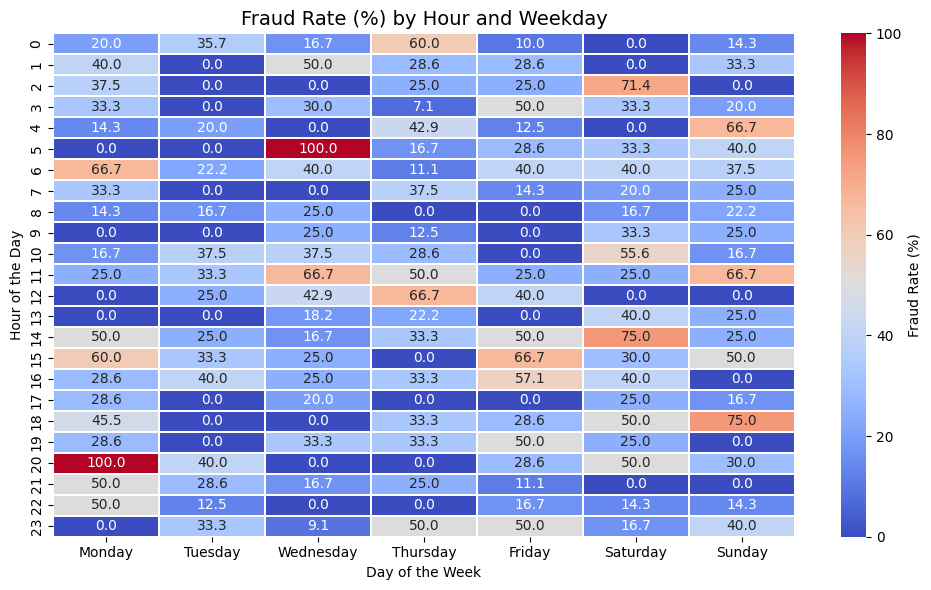

In [ ]:
# Compare proportion of frauds per hour/day
fraud_rate = (fraud_only / all_incidents).fillna(0) * 100

plt.figure(figsize=(10,6))
sns.heatmap(
    fraud_rate,
    cmap='coolwarm',
    linewidths=0.3,
    annot=True,
    fmt=".1f",
    cbar_kws={'label': 'Fraud Rate (%)'}
)
plt.title('Fraud Rate (%) by Hour and Weekday', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Hour of the Day')
plt.tight_layout()
plt.show()

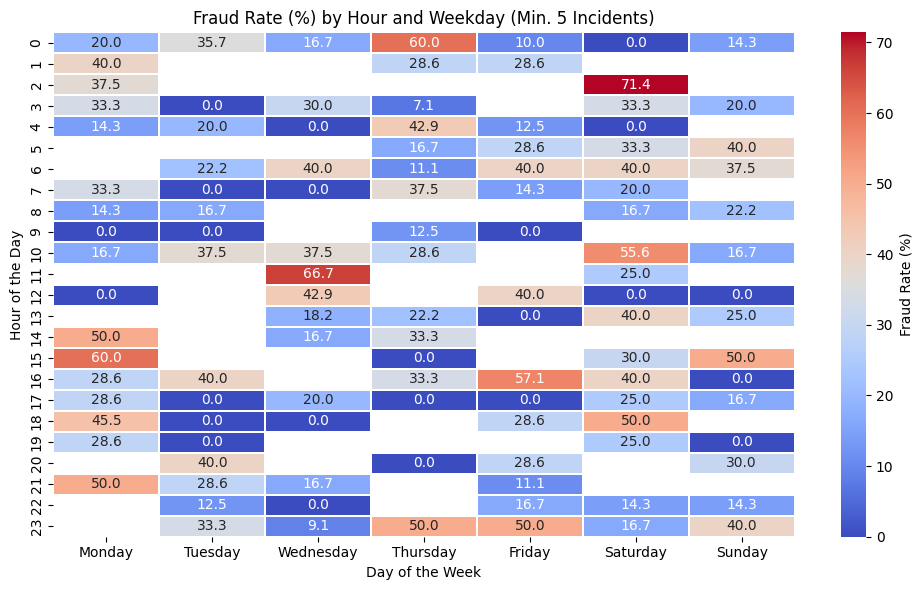

In [ ]:
fraud_rate_filtered = fraud_rate.where(all_incidents >= 5)

plt.figure(figsize=(10,6))
sns.heatmap(
    fraud_rate_filtered,
    cmap='coolwarm',
    linewidths=0.3,
    annot=True,
    fmt=".1f",
    cbar_kws={'label': 'Fraud Rate (%)'}
)
plt.title('Fraud Rate (%) by Hour and Weekday (Min. 5 Incidents)')
plt.xlabel('Day of the Week')
plt.ylabel('Hour of the Day')
plt.tight_layout()
plt.show()

In [ ]:
rate('authorities_contacted')
rate('police_report_available')
rate('witnesses')
rate('insured_relationship')
rate(pd.cut(claimdf['capital-gains'], bins=[-1,0,20000,100500]))


/tmp/ipython-input-1878030762.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,fraud_reported
capital-gains,
"(0, 20000]",0.272727
"(-1, 0]",0.253937
"(20000, 100500]",0.239583


In [ ]:

from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def inspect_cat(col):
    print(f"\n=== {col} ===")

    # 1. Frequency
    counts = claimdf[col].value_counts(dropna=False)
    print("\nCounts:")
    print(counts)

    # 2. Fraud rate
    fraud_rate = (claimdf.groupby(col)['fraud_reported']
                  .apply(lambda x: (x=='Y').mean())
                  .sort_values(ascending=False))
    print("\nFraud rate (%):")
    print((fraud_rate*100).round(2))

    # 3. Chi-square
    table = pd.crosstab(claimdf[col], claimdf['fraud_reported'])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"\nChi-square p-value: {p:.5f}")

    # 4. Cramer's V
    def cramers_v(ct):
        chi2 = chi2_contingency(ct)[0]
        n = ct.sum().sum()
        r, k = ct.shape
        return np.sqrt((chi2/n) / (min(r-1, k-1)))

    print(f"Cramer's V: {cramers_v(table):.3f}")

    # 5. Missing / Unknown flag
    missing = claimdf[col].isin(['?', 'Unknown']).mean() * 100
    print(f"Missing/Unknown: {missing:.1f}%")

    # 6. Visualization (optional)
    plt.figure(figsize=(6,4))


In [ ]:
inspect_cat('insured_relationship')
inspect_cat('authorities_contacted')
inspect_cat('police_report_available')
inspect_cat('witnesses')
inspect_cat('collision_type')
inspect_cat('incident_state')
inspect_cat('insured_education_level')
inspect_cat('insured_occupation')
inspect_cat('insured_hobbies')
inspect_cat('number_of_vehicles_involved')
inspect_cat('bodily_injuries')
inspect_cat('property_damage')





=== insured_relationship ===

Counts:
insured_relationship
Own-Child         183
Other-Relative    177
Not-In-Family     173
Husband           170
Wife              155
Unmarried         141
Name: count, dtype: int64

Fraud rate (%):
insured_relationship
Other-Relative    29.38
Wife              27.10
Not-In-Family     26.01
Unmarried         24.11
Own-Child         21.31
Husband           20.59
Name: fraud_reported, dtype: float64

Chi-square p-value: 0.36692
Cramer's V: 0.074
Missing/Unknown: 0.0%

=== authorities_contacted ===

Counts:
authorities_contacted
Police       291
Fire         223
Other        198
Ambulance    196
Unknown       91
Name: count, dtype: int64

Fraud rate (%):
authorities_contacted
Other        31.82
Ambulance    29.08
Fire         26.91
Police       20.96
Unknown       6.59
Name: fraud_reported, dtype: float64

Chi-square p-value: 0.00003
Cramer's V: 0.162
Missing/Unknown: 9.1%

=== police_report_available ===

Counts:
police_report_available
Unknown    343


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

...

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [ ]:
for col in claimdf.select_dtypes(include='object').columns:
    if col != 'fraud_reported':  # skip target
        inspect_cat(col)



=== policy_state ===

Counts:
policy_state
Oh    352
Il    338
In    309
Name: count, dtype: int64

Fraud rate (%):
policy_state
Oh    25.85
In    25.57
Il    22.78
Name: fraud_reported, dtype: float64

Chi-square p-value: 0.59329
Cramer's V: 0.032
Missing/Unknown: 0.0%

=== policy_csl ===

Counts:
policy_csl
250/500     350
100/300     349
500/1000    300
Name: count, dtype: int64

Fraud rate (%):
policy_csl
250/500     26.29
100/300     25.79
500/1000    21.67
Name: fraud_reported, dtype: float64

Chi-square p-value: 0.33662
Cramer's V: 0.047
Missing/Unknown: 0.0%

=== insured_sex ===

Counts:
insured_sex
Female    537
Male      462
Name: count, dtype: int64

Fraud rate (%):
insured_sex
Male      26.19
Female    23.46
Name: fraud_reported, dtype: float64

Chi-square p-value: 0.35626
Cramer's V: 0.029
Missing/Unknown: 0.0%

=== insured_education_level ===

Counts:
insured_education_level
Jd             161
High School    160
Associate      145
Md             144
Masters        143
Ph

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

...

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [ ]:
from scipy.stats import mannwhitneyu

def inspect_num(col):
    fraud = claimdf[claimdf['fraud_reported']=='Y'][col]
    nonfraud = claimdf[claimdf['fraud_reported']=='N'][col]
    stat, p = mannwhitneyu(fraud, nonfraud)
    print(f"\n=== {col} ===")
    print(f"Median (Fraud Y): {fraud.median():.1f}")
    print(f"Median (Fraud N): {nonfraud.median():.1f}")
    p_str = "SIGNIFICANT ✅" if p<0.05 else "NS ❌"
    print(f"p={p:.5f} → {p_str}")

    sns.boxplot(data=claimdf, x='fraud_reported', y=col)
    plt.show()



=== months_as_customer ===
Median (Fraud Y): 199.0
Median (Fraud N): 199.5
p=0.61299 → NS ❌


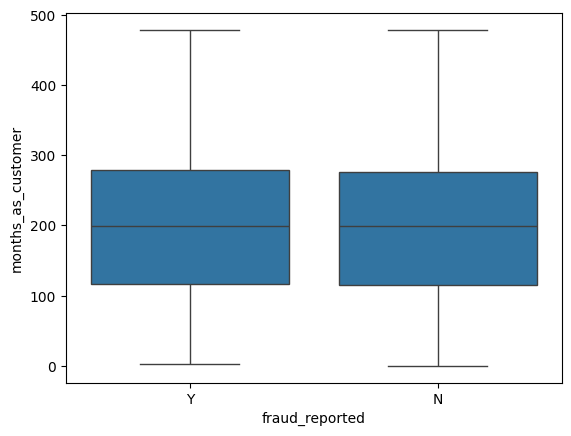


=== age ===
Median (Fraud Y): 38.0
Median (Fraud N): 38.0
p=0.88966 → NS ❌


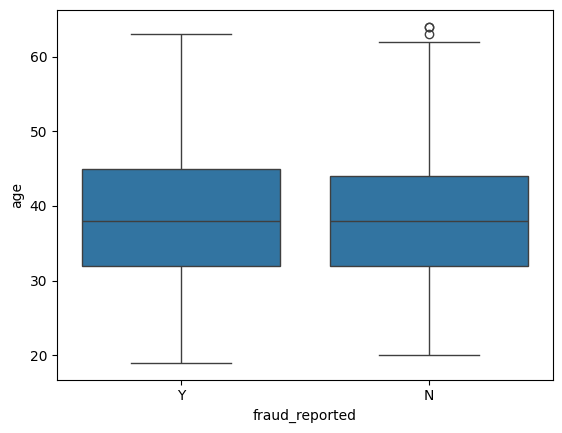


=== policy_deductable ===
Median (Fraud Y): 1000.0
Median (Fraud N): 1000.0
p=0.82316 → NS ❌


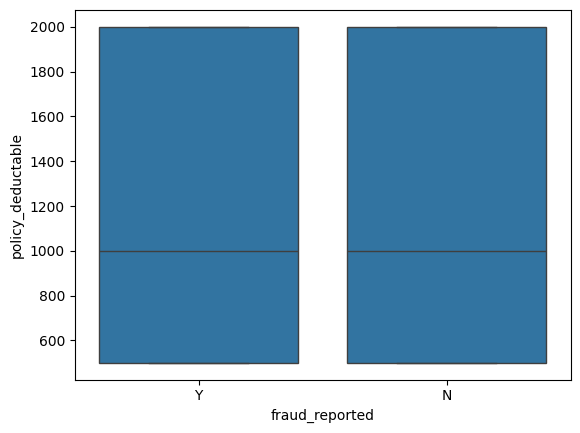


=== policy_annual_premium ===
Median (Fraud Y): 1269.6
Median (Fraud N): 1253.3
p=0.61103 → NS ❌


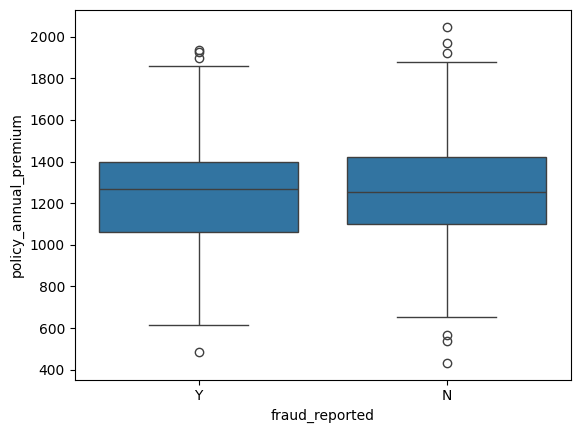


=== umbrella_limit ===
Median (Fraud Y): 0.0
Median (Fraud N): 0.0
p=0.06863 → NS ❌


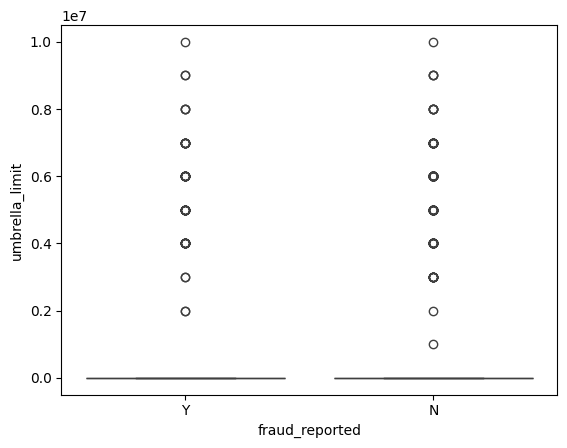


=== insured_zip ===
Median (Fraud Y): 469853.0
Median (Fraud N): 465670.5
p=0.05042 → NS ❌


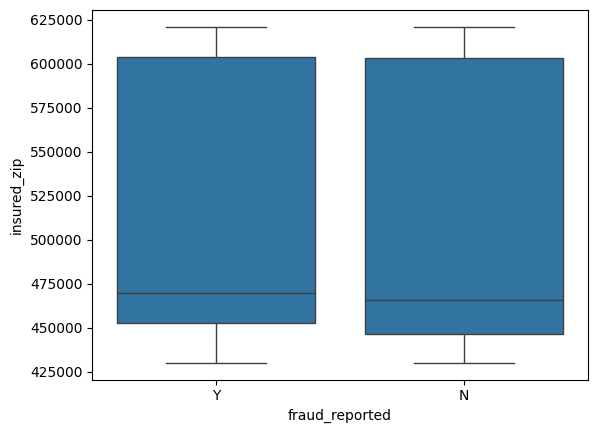


=== capital-gains ===
Median (Fraud Y): 0.0
Median (Fraud N): 0.0
p=0.52272 → NS ❌


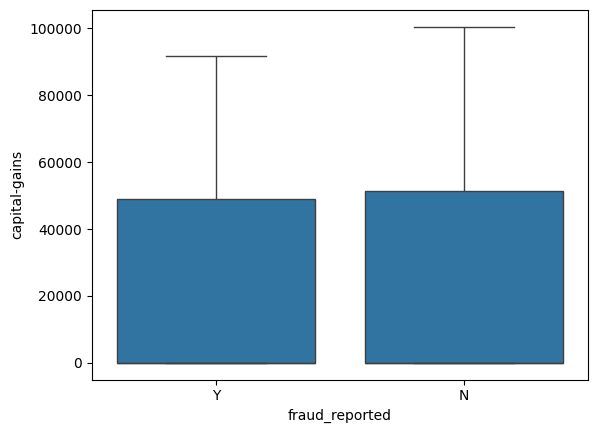


=== capital-loss ===
Median (Fraud Y): -30200.0
Median (Fraud N): -20600.0
p=0.63991 → NS ❌


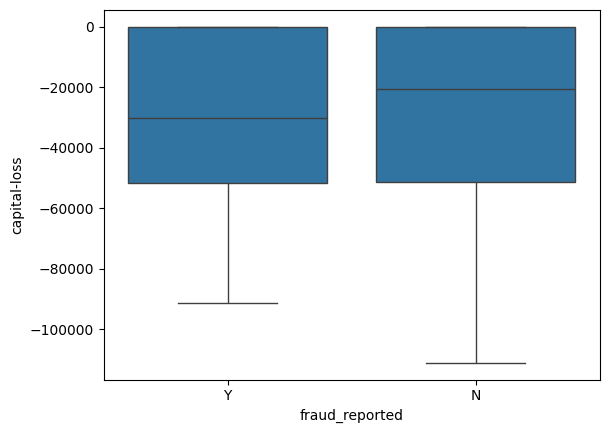


=== incident_hour_of_the_day ===
Median (Fraud Y): 12.0
Median (Fraud N): 12.0
p=0.88912 → NS ❌


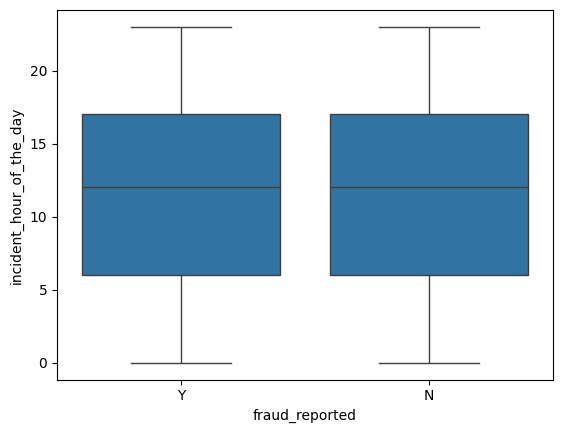


=== number_of_vehicles_involved ===
Median (Fraud Y): 1.0
Median (Fraud N): 1.0
p=0.10168 → NS ❌


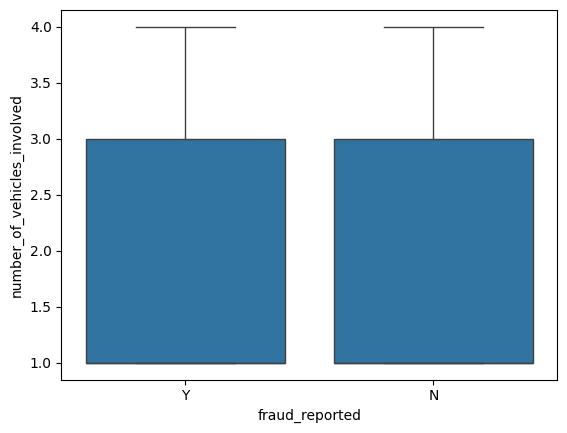


=== bodily_injuries ===
Median (Fraud Y): 1.0
Median (Fraud N): 1.0
p=0.28538 → NS ❌


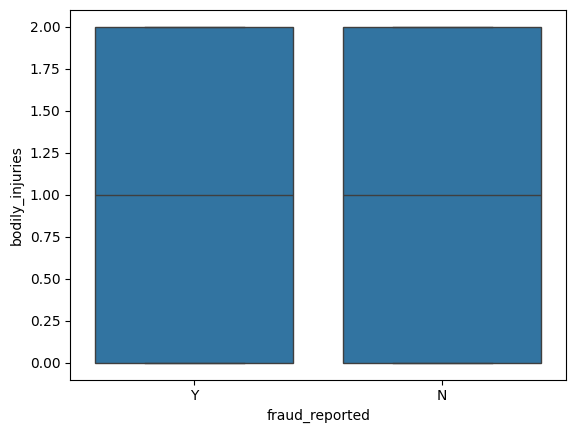


=== witnesses ===
Median (Fraud Y): 2.0
Median (Fraud N): 1.0
p=0.10871 → NS ❌


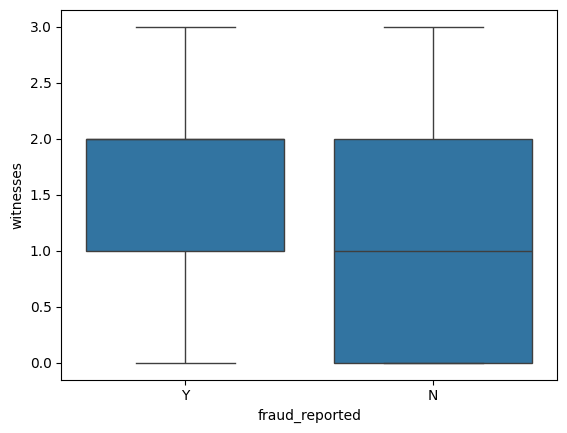


=== total_claim_amount ===
Median (Fraud Y): 61290.0
Median (Fraud N): 56560.0
p=0.00001 → SIGNIFICANT ✅


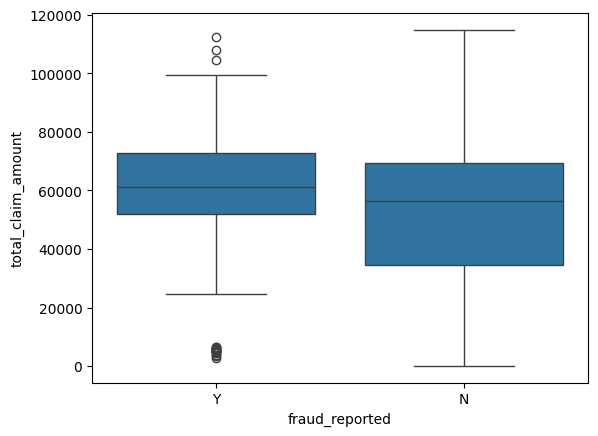


=== injury_claim ===
Median (Fraud Y): 7240.0
Median (Fraud N): 6620.0
p=0.00537 → SIGNIFICANT ✅


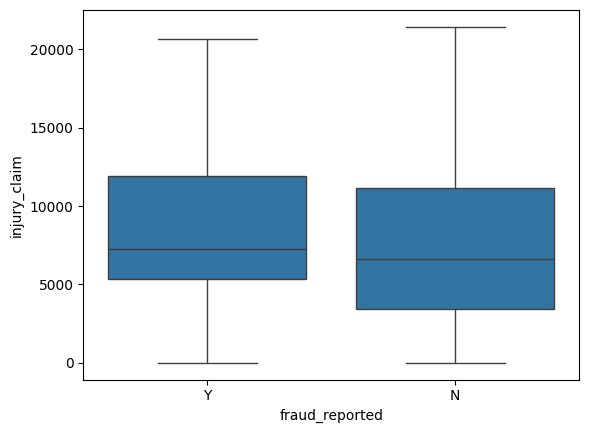


=== property_claim ===
Median (Fraud Y): 7440.0
Median (Fraud N): 6555.0
p=0.00002 → SIGNIFICANT ✅


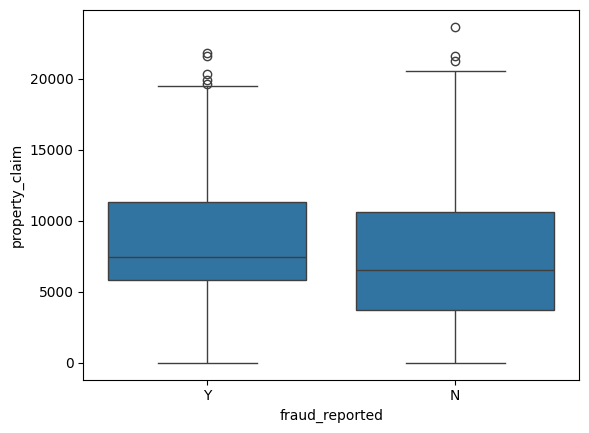


=== vehicle_claim ===
Median (Fraud Y): 44800.0
Median (Fraud N): 41260.0
p=0.00001 → SIGNIFICANT ✅


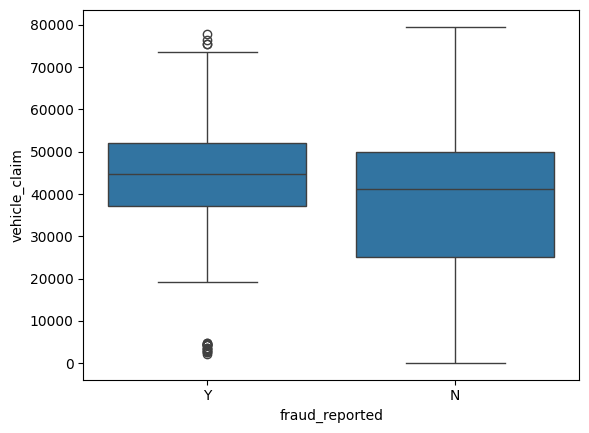


=== policy_age_days ===
Median (Fraud Y): 4638.0
Median (Fraud N): 4734.5
p=0.98885 → NS ❌


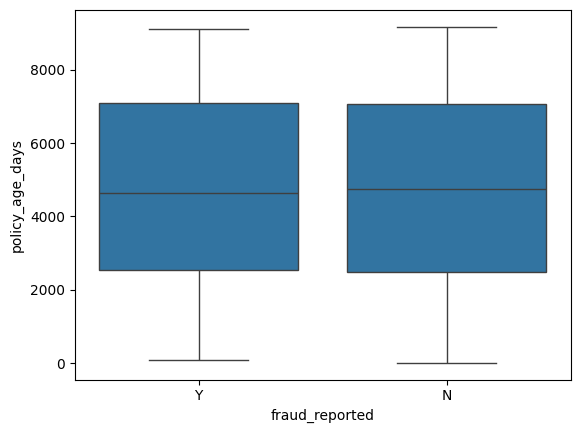


=== vehicle_age ===
Median (Fraud Y): 9.0
Median (Fraud N): 10.0
p=0.79589 → NS ❌


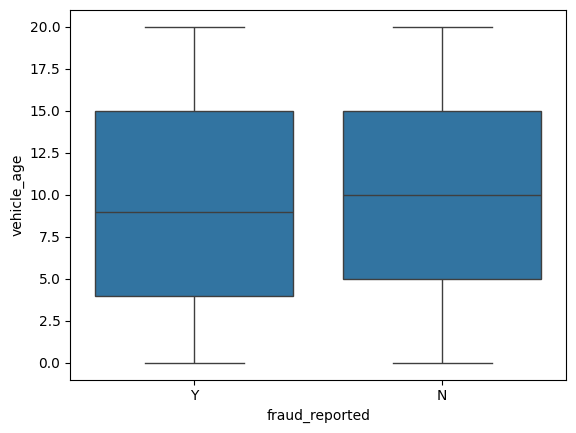

In [ ]:
for col in claimdf.select_dtypes(include=['int64', 'float64']).columns:
    inspect_num(col)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# helper log col
claimdf['log_total_claim'] = np.log1p(claimdf['total_claim_amount'])


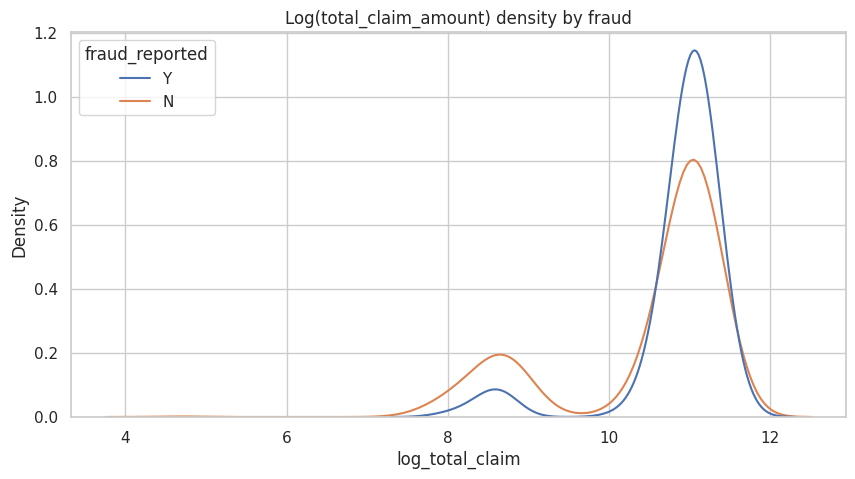

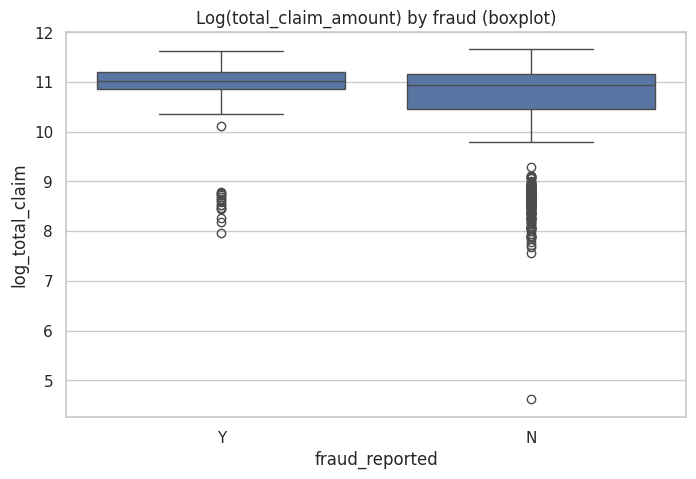

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=claimdf, x='log_total_claim', hue='fraud_reported', common_norm=False)
plt.title('Log(total_claim_amount) density by fraud')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='fraud_reported', y='log_total_claim', data=claimdf)
plt.title('Log(total_claim_amount) by fraud (boxplot)')
plt.show()


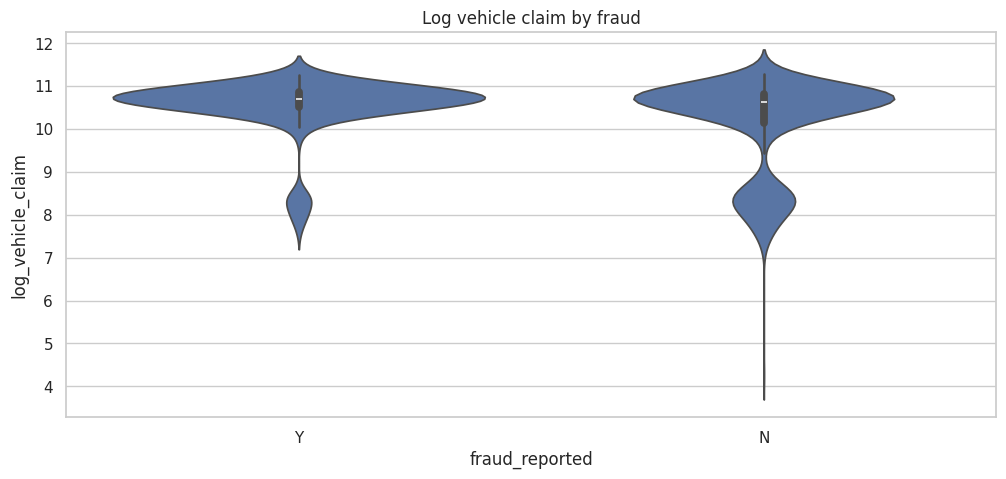

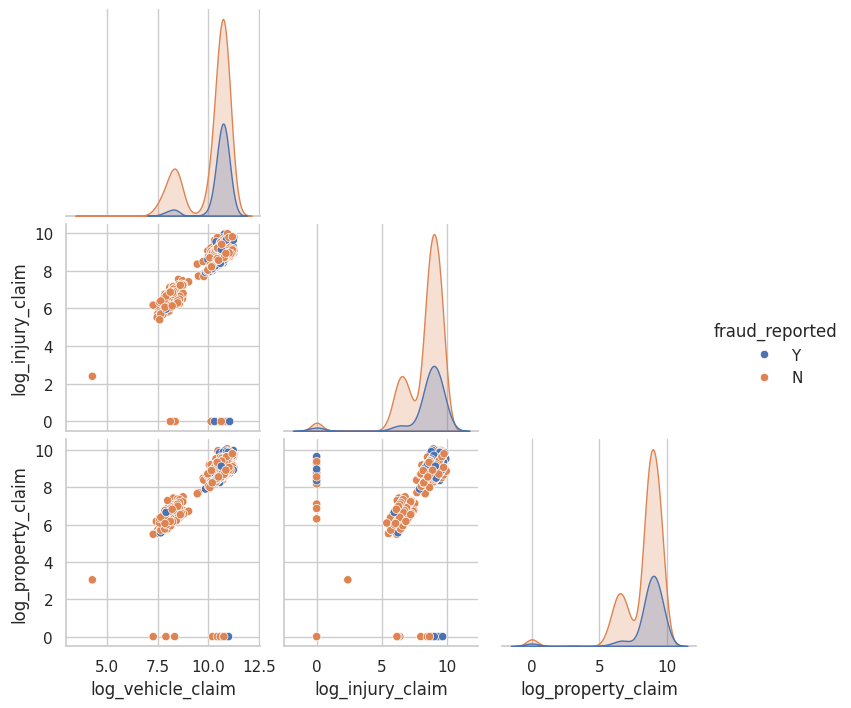

In [ ]:
for col in ['vehicle_claim','injury_claim','property_claim']:
    claimdf[f'log_{col}'] = np.log1p(claimdf[col])

plt.figure(figsize=(12,5))
sns.violinplot(x='fraud_reported', y='log_vehicle_claim', data=claimdf)
plt.title('Log vehicle claim by fraud')
plt.show()

sns.pairplot(claimdf, vars=['log_vehicle_claim','log_injury_claim','log_property_claim'],
             hue='fraud_reported', height=2.4, corner=True)



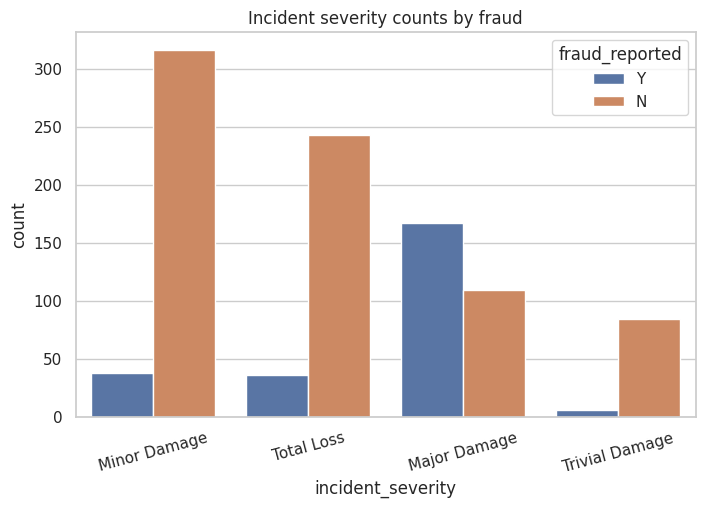

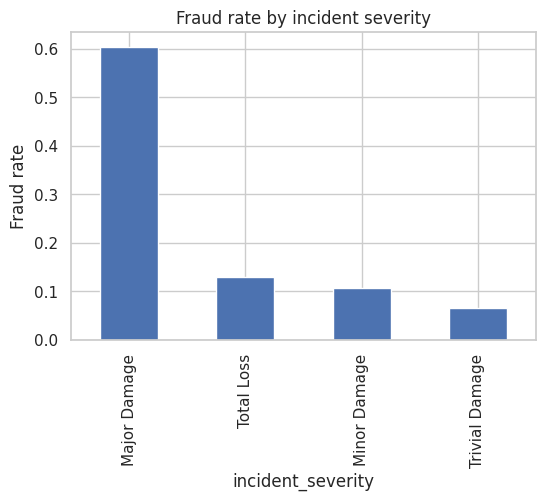

In [ ]:
plt.figure(figsize=(8,5))
order = claimdf['incident_severity'].value_counts().index
ax = sns.countplot(data=claimdf, x='incident_severity', hue='fraud_reported', order=order)
plt.title('Incident severity counts by fraud')
plt.xticks(rotation=15)
plt.show()

# fraud rate per severity
sev = claimdf.groupby('incident_severity')['fraud_reported'].apply(lambda s: (s=='Y').mean()).sort_values(ascending=False)
sev.plot(kind='bar', figsize=(6,4), ylabel='Fraud rate')
plt.title('Fraud rate by incident severity')
plt.show()



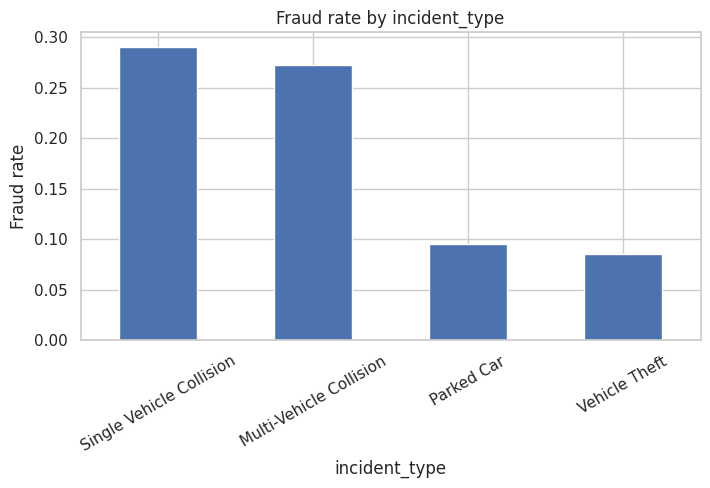

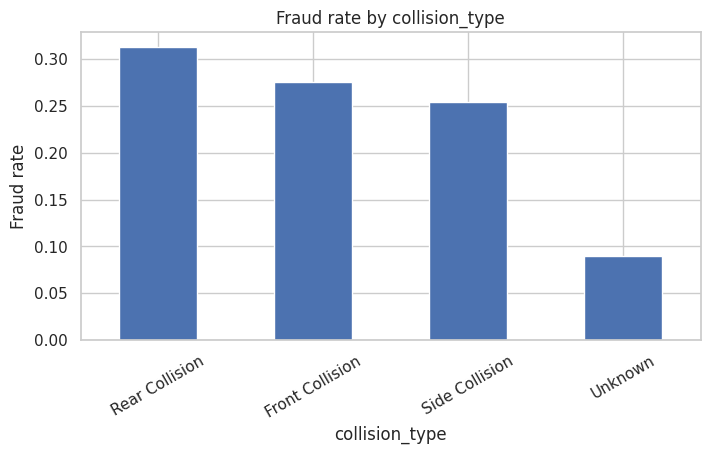

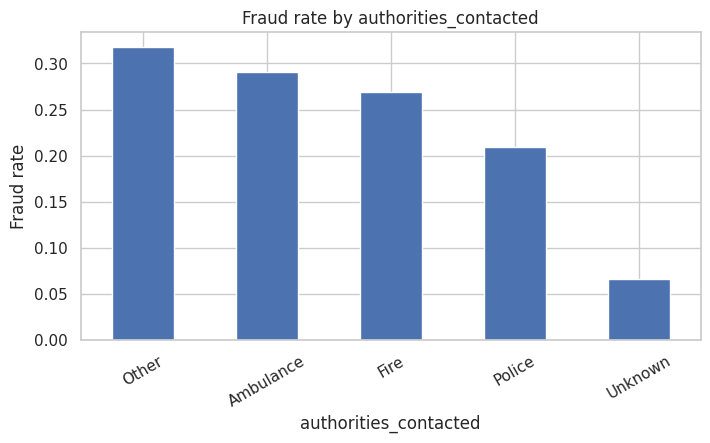

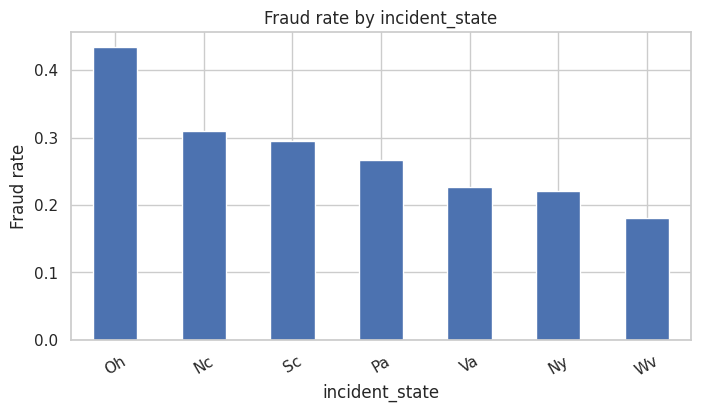

In [ ]:
cats = ['incident_type','collision_type','authorities_contacted','incident_state']
for c in cats:
    plt.figure(figsize=(8,4))
    frac = claimdf.groupby(c)['fraud_reported'].apply(lambda s: (s=='Y').mean()).sort_values(ascending=False)
    frac.plot(kind='bar')
    plt.title(f'Fraud rate by {c}')
    plt.ylabel('Fraud rate')
    plt.xticks(rotation=30)
    plt.show()


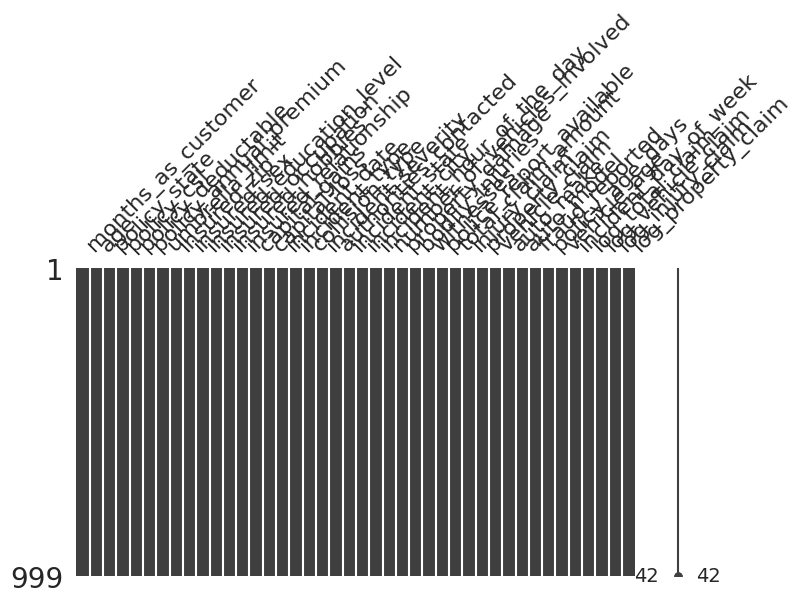

property_damage
property_damage
No         0.195266
Unknown    0.286111
Yes        0.259136
Name: fraud_reported, dtype: float64
---
police_report_available
police_report_available
No         0.250729
Unknown    0.259475
Yes        0.230032
Name: fraud_reported, dtype: float64
---
authorities_contacted
authorities_contacted
Ambulance    0.290816
Fire         0.269058
Other        0.318182
Police       0.209622
Unknown      0.065934
Name: fraud_reported, dtype: float64
---


In [ ]:
import missingno as msno
msno.matrix(claimdf, figsize=(8,4))
plt.show()

for c in ['property_damage','police_report_available','authorities_contacted']:
    print(c)
    print(claimdf.groupby(claimdf[c].fillna('?'))['fraud_reported'].apply(lambda s: (s=='Y').mean()))
    print('---')


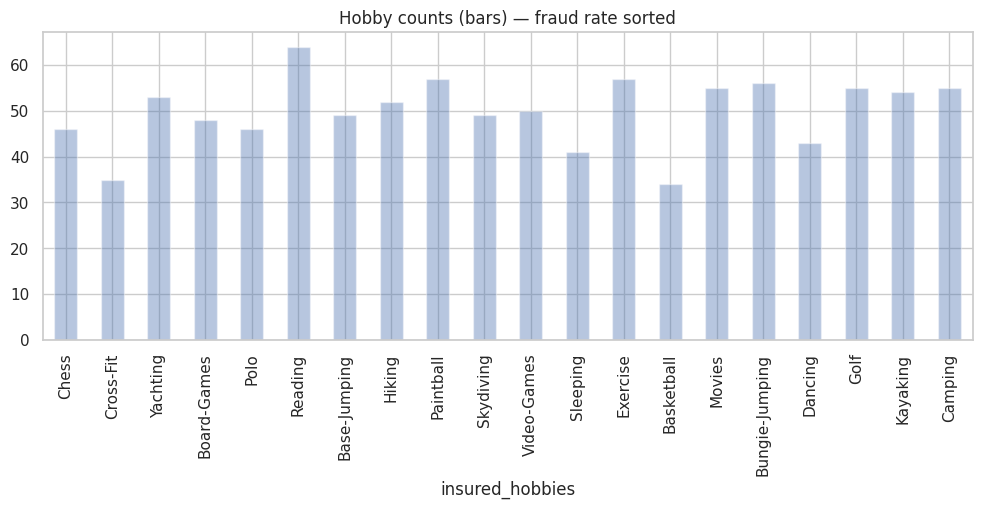

,total,fraud_rate
insured_hobbies,,
Chess,46,0.826087
Cross-Fit,35,0.742857
Yachting,53,0.301887
Board-Games,48,0.291667
Polo,46,0.282609
Reading,64,0.265625
Base-Jumping,49,0.265306
Hiking,52,0.230769
Paintball,57,0.228070


In [ ]:
h = claimdf.groupby('insured_hobbies').agg(total=('fraud_reported','size'),
                                            fraud_rate=('fraud_reported', lambda s: (s=='Y').mean())).sort_values('fraud_rate', ascending=False)
h['total'].plot(kind='bar', figsize=(12,4), alpha=0.4)
plt.title('Hobby counts (bars) — fraud rate sorted')
plt.show()
display(h.head(15))


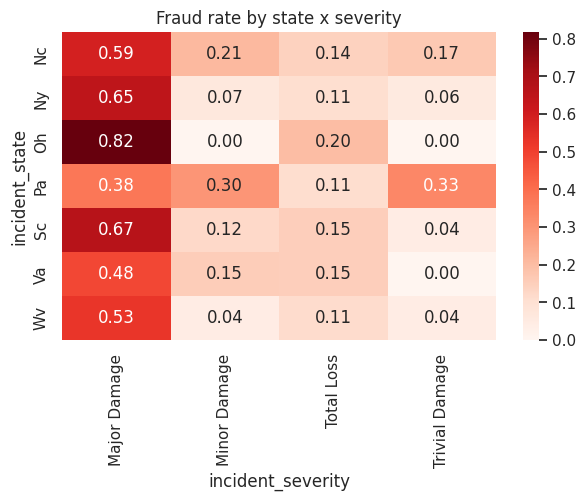

In [ ]:
pt = claimdf.pivot_table(index='incident_state', columns='incident_severity',
                         values='fraud_reported', aggfunc=lambda s: (s=='Y').mean())
plt.figure(figsize=(7,4))
sns.heatmap(pt, annot=True, fmt='.2f', cmap='Reds')
plt.title('Fraud rate by state x severity')
plt.show()


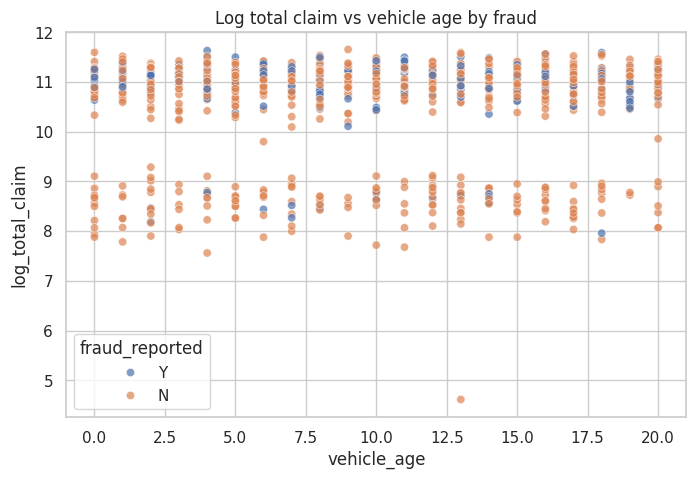

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=claimdf, x='vehicle_age', y='log_total_claim', hue='fraud_reported', alpha=0.7)
plt.title('Log total claim vs vehicle age by fraud')
plt.show()


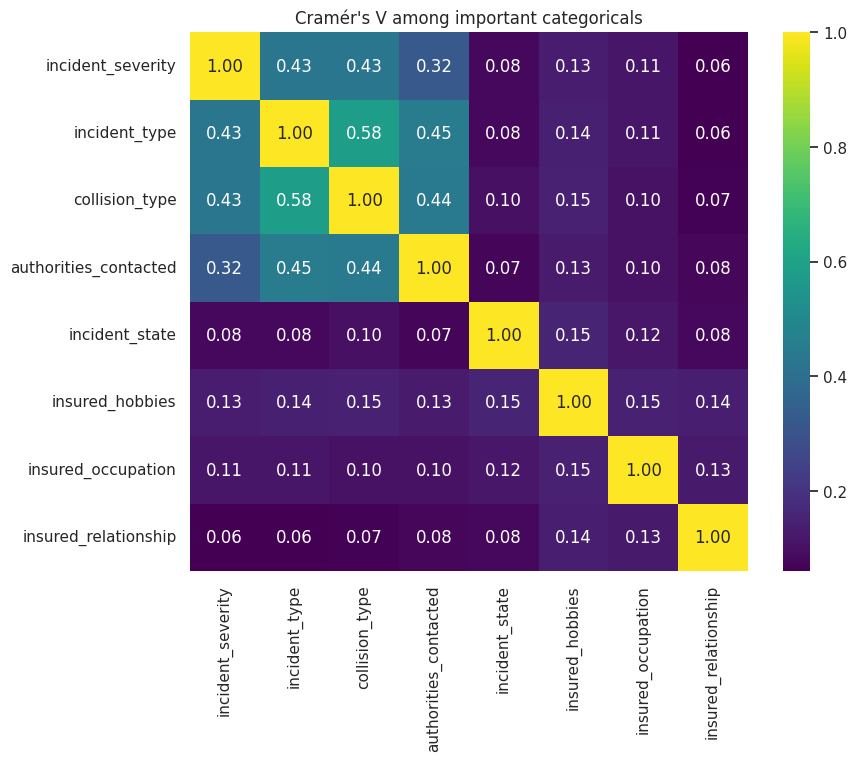

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x,y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2/n
    r,k = ct.shape
    return np.sqrt(phi2 / min(k-1, r-1))

cats = ['incident_severity','incident_type','collision_type','authorities_contacted','incident_state','insured_hobbies','insured_occupation','insured_relationship']
cv = pd.DataFrame(index=cats, columns=cats)
for a in cats:
    for b in cats:
        cv.loc[a,b] = cramers_v(claimdf[a], claimdf[b])
cv = cv.astype(float)
plt.figure(figsize=(9,7))
sns.heatmap(cv, annot=True, fmt='.2f', cmap='viridis')
plt.title("Cramér's V among important categoricals")
plt.show()


In [ ]:
exclusive = (
    claimdf.groupby('insured_hobbies')['fraud_reported']
    .apply(lambda x: set(x))
    .reset_index()
)

exclusive[exclusive['fraud_reported'].apply(lambda s: len(s)==1)]


,insured_hobbies,fraud_reported


In [ ]:
hobby_stats = (
    claimdf.groupby('insured_hobbies')
    .agg(
        total=('fraud_reported','size'),
        fraud_rate=('fraud_reported', lambda s: (s=='Y').mean())
    )
    .sort_values('fraud_rate', ascending=False)
)

hobby_stats


,total,fraud_rate
insured_hobbies,,
Chess,46,0.826087
Cross-Fit,35,0.742857
Yachting,53,0.301887
Board-Games,48,0.291667
Polo,46,0.282609
Reading,64,0.265625
Base-Jumping,49,0.265306
Hiking,52,0.230769
Paintball,57,0.228070


In [ ]:
# Very low sample categories
rare = hobby_stats[hobby_stats['total'] < 5]

# Very high fraud-rate categories
leaky = hobby_stats[hobby_stats['fraud_rate'] > 0.75]

rare, leaky


(Empty DataFrame
 Columns: [total, fraud_rate]
 Index: [],
                  total  fraud_rate
 insured_hobbies                   
 Chess               46    0.826087)

In [ ]:
hobby_stats['likely_leak'] = (
    (hobby_stats['total'] < 5) |
    (hobby_stats['fraud_rate'] > 0.7)
)

hobby_stats


,total,fraud_rate,likely_leak
insured_hobbies,,,
Chess,46,0.826087,True
Cross-Fit,35,0.742857,True
Yachting,53,0.301887,False
Board-Games,48,0.291667,False
Polo,46,0.282609,False
Reading,64,0.265625,False
Base-Jumping,49,0.265306,False
Hiking,52,0.230769,False
Paintball,57,0.228070,False


In [ ]:
claimdf = claimdf.replace('?', np.nan)


claimdf.isna().sum().sort_values(ascending=False).head(10)


In [ ]:
claimdf.isna().sum().sort_values(ascending=False).head(10)


,0
months_as_customer,0
age,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0
insured_sex,0
insured_education_level,0


In [ ]:
claimdf['property_damage_missing'] = (claimdf['property_damage'] == 'Unknown').astype(int)
claimdf['police_report_missing'] = (claimdf['police_report_available'] == 'Unknown').astype(int)
claimdf['authorities_missing'] = (claimdf['authorities_contacted'] == 'Unknown').astype(int)


In [ ]:
rate('authorities_missing')


,fraud_reported
authorities_missing,
0,0.265419
1,0.065934


In [ ]:
rate('police_report_missing')


,fraud_reported
police_report_missing,
1,0.259475
0,0.240854


In [ ]:
rate('property_damage_missing')


,fraud_reported
property_damage_missing,
1,0.286111
0,0.225352


In [ ]:
claimdf['evasive_profile'] = (
    claimdf['property_damage_missing'] +
    claimdf['police_report_missing'] +
    claimdf['authorities_missing']
)


In [ ]:
rate('evasive_profile')


,fraud_reported
evasive_profile,
2,0.263158
1,0.256522
0,0.236074
3,0.000000


In [ ]:
claimdf['evasive_profile_bin'] = pd.cut(
    claimdf['evasive_profile'],
    bins=[-1,0,1,3],
    labels=['None','Some','High']
)
rate('evasive_profile_bin')


/tmp/ipython-input-1878030762.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,fraud_reported
evasive_profile_bin,
Some,0.256522
High,0.246914
None,0.236074


In [ ]:
claimdf = claimdf.replace('?', np.nan)


In [ ]:
# --- months_as_customer: keep raw, no buckets; add 12m binary flag ---

# 0) Sanity: the column must exist and be numeric-like
assert 'months_as_customer' in claimdf.columns, "months_as_customer is missing."
if not (pd.api.types.is_integer_dtype(claimdf['months_as_customer'])
        or pd.api.types.is_float_dtype(claimdf['months_as_customer'])):
    # try coercion if it somehow came in as string
    claimdf['months_as_customer'] = pd.to_numeric(claimdf['months_as_customer'], errors='coerce')

# 1) Drop any previously created bucket feature (if present)
for col in ['tenure_bucket']:
    if col in claimdf.columns:
        claimdf.drop(columns=[col], inplace=True)

# 2) Remove old binary (<6m) if you created it and you want only the 12m flag
if 'is_new_customer' in claimdf.columns:
    claimdf.drop(columns=['is_new_customer'], inplace=True)

# 3) Create wider binary flag: "is_new_12m" (tenure < 12 months)
#    - keeps raw months_as_customer untouched
#    - easier to get enough support in each class for modeling
claimdf['is_new_12m'] = (claimdf['months_as_customer'] < 12).astype('int8')

# 4) Quick QC / profile
mn, mx = claimdf['months_as_customer'].min(), claimdf['months_as_customer'].max()
print(f"months_as_customer range: {int(mn)} → {int(mx)}")
print("is_new_12m counts:")
print(claimdf['is_new_12m'].value_counts().rename({0:'≥12m',1:'<12m'}))


months_as_customer range: 0 → 479
is_new_12m counts:
is_new_12m
≥12m    975
<12m     24
Name: count, dtype: int64


In [ ]:
# 1) Does <12m actually correlate with fraud?
rate_by_flag = (
    claimdf.groupby('is_new_12m')['fraud_reported']
           .apply(lambda s: (s=='Y').mean())
           .rename({0:'≥12m', 1:'<12m'})
           .mul(100).round(2)
)
print("Fraud rate (%):\n", rate_by_flag)

# 2) Test significance (2x2)
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

tbl = pd.crosstab(claimdf['is_new_12m'], claimdf['fraud_reported'])
chi2, p, *_ = chi2_contingency(tbl)
print(f"Chi2 p={p:.4f}  table=\n{tbl}")

# Fisher is stable for small cells
odds, pf = fisher_exact(tbl)
print(f"Fisher p={pf:.4f}, odds ratio={odds:.2f}")

# 3) Compare raw months vs fraud (non-parametric)
from scipy.stats import mannwhitneyu
f = claimdf.loc[claimdf['fraud_reported']=='Y', 'months_as_customer']
n = claimdf.loc[claimdf['fraud_reported']=='N', 'months_as_customer']
u, p = mannwhitneyu(f, n, alternative='two-sided')
print(f"Mann–Whitney U p={p:.4f} (raw months)")



Fraud rate (%):
 is_new_12m
≥12m    24.62
<12m    29.17
Name: fraud_reported, dtype: float64
Chi2 p=0.7863  table=
fraud_reported    N    Y
is_new_12m              
0               735  240
1                17    7
Fisher p=0.6330, odds ratio=1.26
Mann–Whitney U p=0.6130 (raw months)


In [ ]:
# Safety: ensure numeric + no NaNs sneak in
claimdf['months_as_customer'] = pd.to_numeric(claimdf['months_as_customer'], errors='coerce')
assert claimdf['months_as_customer'].isna().sum() == 0, "Unexpected NaNs in months_as_customer"

# Make sure derived flag exists and is int
claimdf['is_new_12m'] = (claimdf['months_as_customer'] < 12).astype('int8')


In [ ]:
# --- AGE: keep raw, validate, optional 50+ flag ---

# 0) Ensure column exists & numeric
assert 'age' in claimdf.columns, "age column missing."
claimdf['age'] = pd.to_numeric(claimdf['age'], errors='coerce')

# 1) Basic sanity checks
n_na = claimdf['age'].isna().sum()
mn, mx = claimdf['age'].min(), claimdf['age'].max()
print(f"age: NaNs={n_na}, range={mn:.0f}→{mx:.0f}")
assert n_na == 0, "Unexpected NaNs in age"
assert (mn >= 18) and (mx <= 100), "Age out of plausible range detected (18..100 check)."

# 2) (Optional) coarse nonlinearity flag: age ≥ 50
#    Keeps raw age untouched; small, interpretable addition.
if 'age_50plus' in claimdf.columns:
    claimdf.drop(columns=['age_50plus'], inplace=True)
claimdf['age_50plus'] = (claimdf['age'] >= 50).astype('int8')

# 3) (Optional) quick univariate check against fraud (for report notes; no frame mutation)
from scipy.stats import mannwhitneyu
f = claimdf.loc[claimdf['fraud_reported']=='Y', 'age']
n = claimdf.loc[claimdf['fraud_reported']=='N', 'age']
u, p = mannwhitneyu(f, n, alternative='two-sided')
print(f"Mann–Whitney U on age vs fraud: p={p:.4f}")


age: NaNs=0, range=19→64
Mann–Whitney U on age vs fraud: p=0.8897


In [ ]:
# Optional, interpretable rule
claimdf['policy_is_new_90d'] = (claimdf['policy_age_days'] < 90).astype('int8')


In [ ]:
# 0) Smoke tests: exists, dtype, preview
assert 'policy_is_new_90d' in claimdf.columns, "Column wasn't created."
print("dtype:", claimdf['policy_is_new_90d'].dtype)
display(claimdf[['policy_age_days','policy_is_new_90d']].head())

# 1) Distribution of the flag
vc = claimdf['policy_is_new_90d'].value_counts().rename({0: '≥90d', 1: '<90d'})
print("Counts:\n", vc)

# 2) Sanity: does the flag match the rule near the threshold?
edge = claimdf.loc[claimdf['policy_age_days'].between(80, 100)][
    ['policy_age_days','policy_is_new_90d']
].sort_values('policy_age_days')
display(edge.head(12))  # should be 1 for <90, 0 for >=90

# 3) Quick group stats
print(
    claimdf.groupby('policy_is_new_90d')['policy_age_days']
           .agg(['count','min','median','max'])
)

# 4) Relationship to target (rates + tests)
tbl = pd.crosstab(claimdf['policy_is_new_90d'], claimdf['fraud_reported'])
print("Contingency table:\n", tbl)

row_rates = (tbl.T / tbl.sum(axis=1)).T * 100
print("Fraud rate (%) by flag:\n", row_rates['Y'].round(2))

from scipy.stats import chi2_contingency, fisher_exact
chi2, p, *_ = chi2_contingency(tbl)
odds, pf = fisher_exact(tbl)
print(f"chi2 p={p:.4f} | fisher p={pf:.4f} | odds ratio={odds:.2f}")


dtype: int8


,policy_age_days,policy_is_new_90d
0,100,0
1,3130,0
2,5282,0
3,8996,0
4,256,0


Counts:
 policy_is_new_90d
≥90d    992
<90d      7
Name: count, dtype: int64


,policy_age_days,policy_is_new_90d
97,82,1
0,100,0


                   count  min  median   max
policy_is_new_90d                          
0                    992  100  4742.0  9172
1                      7    6    46.0    82
Contingency table:
 fraud_reported       N    Y
policy_is_new_90d          
0                  746  246
1                    6    1
Fraud rate (%) by flag:
 policy_is_new_90d
0    24.80
1    14.29
Name: Y, dtype: float64
chi2 p=0.8392 | fisher p=1.0000 | odds ratio=0.51


In [ ]:
claimdf.drop(columns=['policy_is_new_90d'], errors='ignore', inplace=True)


In [ ]:
import numpy as np, pandas as pd
from scipy.stats import fisher_exact

def flag_eval(days):
    f = (claimdf['policy_age_days'] < days).astype(int)
    tbl = pd.crosstab(f, claimdf['fraud_reported'])
    # guard for zero rows
    if tbl.shape != (2,2):
        return {'days': days, 'n_flag': int(f.sum()), 'fraud_flag%': np.nan, 'fisher_p': np.nan}
    fraud_rate_flag = tbl.loc[1,'Y'] / tbl.loc[1].sum() if tbl.loc[1].sum() else np.nan
    _, pf = fisher_exact(tbl)
    return {'days': days, 'n_flag': int(f.sum()), 'fraud_flag%': round(100*fraud_rate_flag,2), 'fisher_p': pf}

pd.DataFrame([flag_eval(d) for d in [90, 120, 180, 270, 365]])


,days,n_flag,fraud_flag%,fisher_p
0,90,7,14.29,1.000000
1,120,10,20.00,1.000000
2,180,16,25.00,1.000000
3,270,32,25.00,1.000000
4,365,42,26.19,0.855177


In [ ]:
# tenure flags created earlier — remove from the global frame
claimdf.drop(columns=[
    'policy_is_new_90d',   # you already dropped, keep here for idempotency
    'is_new_customer',     # old <6m flag if it exists
    'is_new_12m'           # widen/replace inside pipeline if you still want a rule
], errors='ignore', inplace=True)


In [ ]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class PolicyNewFlag(BaseEstimator, TransformerMixin):
    def __init__(self, cutoff_days=365, col='policy_age_days', out_col='policy_is_new_365d'):
        self.cutoff_days = cutoff_days
        self.col = col
        self.out_col = out_col
    def fit(self, X, y=None):
        # no learned params; still keeps the transform train-only
        return self
    def transform(self, X):
        X = X.copy()
        X[self.out_col] = (X[self.col] < self.cutoff_days).astype('int8')
        return X


In [ ]:
# sanity block for policy_age_days

assert 'policy_bind_date' not in claimdf.columns, "policy_bind_date still present"
assert 'policy_age_days' in claimdf.columns, "policy_age_days missing"

# summary without mixing transforms into agg
summary = claimdf['policy_age_days'].agg(['min', 'median', 'max']).to_frame().T
summary['n_na'] = claimdf['policy_age_days'].isna().sum()
print(summary)

# hard checks
assert (claimdf['policy_age_days'] >= 0).all(), "Negative policy_age_days found"
assert claimdf['policy_age_days'].isna().sum() == 0, "NaNs in policy_age_days"


                 min  median     max  n_na
policy_age_days  6.0  4687.0  9172.0     0


In [ ]:
# --- Encode target to binary (1=fraud Y, 0=non-fraud N) ---

# 1) Sanity + normalize casing
assert 'fraud_reported' in claimdf.columns, "fraud_reported missing"
tgt = claimdf['fraud_reported'].astype(str).str.strip().str.upper()

# 2) Validate expected symbols
bad = set(tgt.unique()) - {'Y', 'N'}
assert not bad, f"Unexpected values in fraud_reported: {bad}"

# 3) Map to binary int8 (keep as a separate Series y)
y = tgt.map({'Y': 1, 'N': 0}).astype('int8')

# (Optional) If you prefer to keep it inside the frame as well:
# claimdf['fraud_reported_bin'] = y


In [ ]:
counts = y.value_counts().rename({0:'non-fraud (0)', 1:'fraud (1)'}).sort_index()
fraud_rate = float(y.mean()) * 100

print("Class counts:\n", counts)
print(f"Fraud rate (positives): {fraud_rate:.2f}%")


Class counts:
 fraud_reported
fraud (1)        247
non-fraud (0)    752
Name: count, dtype: int64
Fraud rate (positives): 24.72%


In [ ]:
# Target series checks
y.dtype, y.unique(), y.mean()
# -> (dtype('int8'), array([1, 0], dtype=int8), ~0.247)

# Ensure the original frame still has the string labels (as features, not target)
claimdf['fraud_reported'].head(), claimdf['fraud_reported'].dtype
# -> shows 'Y'/'N' a


(0    Y
 1    Y
 2    N
 3    Y
 4    N
 Name: fraud_reported, dtype: object,
 dtype('O'))

In [ ]:
# make 0/1 target from 'fraud_reported'
y_map = {"Y": 1, "N": 0}
claimdf["target"] = claimdf["fraud_reported"].astype(str).str.strip().str.upper().map(y_map).astype("int8")

In [ ]:
claimdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           999 non-null    int64         
 1   age                          999 non-null    int64         
 2   policy_state                 999 non-null    object        
 3   policy_csl                   999 non-null    object        
 4   policy_deductable            999 non-null    int64         
 5   policy_annual_premium        999 non-null    float64       
 6   umbrella_limit               999 non-null    int64         
 7   insured_zip                  999 non-null    int64         
 8   insured_sex                  999 non-null    object        
 9   insured_education_level      999 non-null    object        
 10  insured_occupation           999 non-null    object        
 11  insured_hobbies              999 non-null    objec